# Call transcripts: what do the conversations look like, and what could cause waiting and unresolved problems?

**Context.** We want to reduce **waiting times** and improve **problem solving**. Call transcripts are the first dataset with the content of the conversations,
so this notebook describes them and makes a first **grouping / clustering iteration** over each `transcript_id`, using the detected intents, main topics, keywords,
entities and the text itself, and then checks whether any group is related to the survey ratings and reasons (transcripts link to surveys by `interaction_id`).

**Questions.**

1. Is the transcript data usable (labels, text, links)?
2. What do the structured columns say (intents, topics, keywords, entities, accent, audio quality, model, duration)?
3. What is in the text, and do the labels agree with it?
4. What groups can be built (rule-based on labels, on text, and a first unsupervised clustering), and how well do they hold?
5. Does any group, or the length of the call, explain waiting-time or unresolved-problem comments and low ratings?

Descriptive only. No language model is trained. Nothing is imputed or invented. The 1,097 daily files (131 MB, with large text columns) are **streamed one at a time**:
only the structured columns and features derived from the text are kept, and process memory is measured.

## 1. Setup and load (streamed)

In [1]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
from IPython.display import display

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
TRANSCRIPTS_ROOT = REPO_ROOT / "data" / "call_transcripts"
SURVEYS_ROOT = REPO_ROOT / "data" / "satisfaction_surveys"
CUSTOMERS_PATH = REPO_ROOT / "data" / "data" / "customers.csv"

BAR_COLOR = "#2E6DB4"
MUTED_COLOR = "#6B7280"
STRUCTURED_COLUMNS = [
    "transcript_id", "interaction_id", "process_date", "customer_id", "agent_id", "detected_language", "detected_accent", "accent_confidence",
    "detected_keywords", "mentioned_entities", "detected_intents", "main_topics", "transcription_model", "audio_quality", "duration_seconds",
]
COLUMNS_TO_READ = STRUCTURED_COLUMNS + ["full_text"]
NEGATIVE_COMMENT_THEMES = {
    "Tardaron mucho en atenderme.": "waiting time",
    "Tuve que esperar demasiado tiempo.": "waiting time",
    "No resolvieron mi problema completamente.": "problem not resolved",
    "No estoy satisfecho con la solución.": "problem not resolved",
    "El agente no fue muy claro en sus explicaciones.": "unclear explanation",
}
REASONS = ["waiting time", "problem not resolved", "unclear explanation"]


def current_memory_mb() -> float:
    """Measures the resident memory of this notebook's process.

    Exists to show the streaming approach stays small on a machine with limited free RAM.

    Args:
        None.

    Returns:
        float: resident set size in megabytes.
    """
    return psutil.Process().memory_info().rss / 1e6


def summarize_partition(path: Path) -> tuple[pd.DataFrame, pd.Series]:
    """Reduces one daily transcript file to its structured columns, text-derived features and a line inventory.

    Exists so the full text can be scanned one file at a time without ever holding all of it in memory.

    Args:
        path: Path of one daily transcript file.

    Returns:
        tuple: (one row per transcript with structured columns and text features, count of every distinct line of dialogue in the file).
    """
    frame = pd.read_csv(path, usecols=COLUMNS_TO_READ)
    text = frame["full_text"].fillna("")
    features = pd.DataFrame({
        "customer_turns": text.str.count("Cliente:"),
        "agent_turns": text.str.count("Agente:"),
        "words": text.str.split().str.len(),
        "opening_line": text.str.extract(r"Cliente: ([^\n]+)")[0],
        "asks_how_long": text.str.contains("cuánto tiempo tarda", regex=False),
        "agent_asks_to_wait": text.str.contains("Permítame un momento", regex=False),
        "has_unfilled_placeholder": text.str.contains(r"\{[a-z]+\}", regex=True),
        "conversation_signature": pd.util.hash_array(text.to_numpy()),
    })
    lines = text.str.split("\n").explode().str.strip()
    return pd.concat([frame[STRUCTURED_COLUMNS], features], axis=1), lines[lines != ""].value_counts()


memory_start_mb = current_memory_mb()
partition_files = sorted(TRANSCRIPTS_ROOT.glob("year=*/month=*/day=*/call_transcripts_*.csv"))
row_parts, line_parts = [], []
peak_memory_mb = memory_start_mb
for path in partition_files:
    rows, lines = summarize_partition(path)
    row_parts.append(rows)
    line_parts.append(lines)
    peak_memory_mb = max(peak_memory_mb, current_memory_mb())

calls = pd.concat(row_parts, ignore_index=True)
line_inventory = pd.concat(line_parts).groupby(level=0).sum().sort_values(ascending=False)
del row_parts, line_parts
calls["process_date"] = pd.to_datetime(calls["process_date"])
display(pd.Series({
    "daily files": len(partition_files), "transcripts": len(calls),
    "first / last process_date": f"{calls['process_date'].min().date()} / {calls['process_date'].max().date()}",
    "distinct customers / agents": f"{calls['customer_id'].nunique():,} / {calls['agent_id'].nunique():,}",
    "peak process memory while streaming, MB": peak_memory_mb,
}, name="value").to_frame())

,value
daily files,1097
transcripts,171321
first / last process_date,2023-06-17 / 2026-06-17
distinct customers / agents,"101,951 / 1,090"
"peak process memory while streaming, MB",298.80


## 2. Structure and data quality

In [2]:
schema = pd.DataFrame({"dtype": calls.dtypes.astype(str), "missing_pct": calls.isna().mean() * 100, "distinct": calls.nunique()})
display(schema)
display(pd.Series({
    "duplicate transcript_id": calls["transcript_id"].duplicated().sum(),
    "duplicate interaction_id": calls["interaction_id"].duplicated().sum(),
    "distinct detected_language": calls["detected_language"].nunique(),
    "distinct detected_intents (excluding missing)": calls["detected_intents"].nunique(),
    "distinct detected_keywords sets": calls["detected_keywords"].nunique(),
    "distinct main_topics": calls["main_topics"].nunique(),
    "distinct mentioned_entities strings": calls["mentioned_entities"].nunique(),
    "duration_seconds: min / max": f"{calls['duration_seconds'].min():.0f} / {calls['duration_seconds'].max():.0f}",
}, name="value").to_frame())

,dtype,missing_pct,distinct
transcript_id,str,0.00,171321
interaction_id,str,0.00,171321
process_date,datetime64[us],0.00,1097
customer_id,str,0.00,101951
agent_id,str,0.00,1090
detected_language,str,0.00,1
detected_accent,str,36.82,3
accent_confidence,float64,10.01,25
detected_keywords,str,5.13,12
mentioned_entities,str,10.02,54


,value
duplicate transcript_id,0
duplicate interaction_id,0
distinct detected_language,1
distinct detected_intents (excluding missing),1
distinct detected_keywords sets,12
distinct main_topics,6
distinct mentioned_entities strings,54
duration_seconds: min / max,30 / 1151


Each transcript has a unique `interaction_id` (the key to surveys). `detected_language` is always `es`, and **`detected_intents` has a single value** (`consulta_general`,
with 4.9% missing), so it cannot separate conversations. `detected_keywords` contains only three words in different orders and subsets, so it does not either. The columns that
can differ between transcripts are `main_topics`, `mentioned_entities`, the accent, audio quality, transcription model, duration and the text itself.

### Links to other datasets

In [3]:
surveys = pd.concat(
    (pd.read_csv(path, usecols=["interaction_id", "customer_id", "agent_id", "survey_type", "main_score", "open_comments", "response_time_hours", "send_channel"])
     for path in sorted(SURVEYS_ROOT.glob("year=*/month=*/day=*/satisfaction_surveys_*.csv"))), ignore_index=True)
surveys["theme"] = surveys["open_comments"].map(NEGATIVE_COMMENT_THEMES)
linked = calls.merge(surveys, on="interaction_id", how="inner", suffixes=("", "_survey"))
customers = pd.read_csv(CUSTOMERS_PATH, usecols=["customer_id"])
display(pd.Series({
    "surveys": len(surveys),
    "surveys whose interaction_id has a transcript": surveys["interaction_id"].isin(calls["interaction_id"]).sum(),
    "  as % of surveys": surveys["interaction_id"].isin(calls["interaction_id"]).mean() * 100,
    "transcripts whose interaction has a survey": calls["interaction_id"].isin(surveys["interaction_id"]).sum(),
    "  as % of transcripts": calls["interaction_id"].isin(surveys["interaction_id"]).mean() * 100,
    "linked pairs: same customer (%)": (linked["customer_id"] == linked["customer_id_survey"]).mean() * 100,
    "linked pairs: same agent (%)": (linked["agent_id"] == linked["agent_id_survey"]).mean() * 100,
    "transcript customers present in customers.csv (%)": calls["customer_id"].isin(customers["customer_id"]).mean() * 100,
}, name="value").to_frame())

,value
surveys,"212,759.00"
surveys whose interaction_id has a transcript,"53,090.00"
as % of surveys,24.95
transcripts whose interaction has a survey,"53,090.00"
as % of transcripts,30.99
linked pairs: same customer (%),100.00
linked pairs: same agent (%),100.00
transcript customers present in customers.csv (%),100.00


Transcripts and surveys **do share `interaction_id`** (a quarter of survey interactions have a transcript), always with the same customer and agent. That is the link
that was missing between the content of a contact and how the customer rated it, and it is used in section 7.

## 3. The structured columns

In [4]:
for column in ["main_topics", "detected_intents", "detected_accent", "audio_quality", "transcription_model"]:
    counts = calls[column].value_counts(dropna=False)
    display(pd.DataFrame({"transcripts": counts, "share_pct": counts / len(calls) * 100}).rename_axis(column))
display(calls["detected_keywords"].value_counts(dropna=False).to_frame("transcripts").head(13))

,transcripts,share_pct
main_topics,,
Transaccional,59786,34.90
Producto,37658,21.98
Queja,29198,17.04
Técnico,25691,15.00
Comercial,13808,8.06
Retención,5180,3.02


,transcripts,share_pct
detected_intents,,
consulta_general,162864,95.06
NaN,8457,4.94


,transcripts,share_pct
detected_accent,,
NaN,63083,36.82
mexican,54152,31.61
colombian,32284,18.84
argentine,21802,12.73


,transcripts,share_pct
audio_quality,,
High,114371,66.76
Medium,40350,23.55
NaN,8638,5.04
Low,7962,4.65


,transcripts,share_pct
transcription_model,,
AWS Transcribe,43117,25.17
Whisper v3,42803,24.98
Google STT,42740,24.95
Azure Speech,42661,24.90


,transcripts
detected_keywords,
"banco, servicio, cuenta",18173
"cuenta, servicio, banco",18116
"cuenta, banco, servicio",18113
"servicio, cuenta, banco",18016
"servicio, banco, cuenta",18016
"banco, cuenta, servicio",17910
"cuenta, banco",9082
"cuenta, servicio",9053
"banco, servicio",9052


In [5]:
def parse_entities(entities: pd.Series) -> pd.DataFrame:
    """Expands the JSON string of mentioned entities into one column per entity type.

    Exists so the entities can be counted and used as grouping features.

    Args:
        entities: JSON strings such as {"account_numbers": 2, "dates": 1, "amounts": 1, "products": "Tarjeta Crédito"}; missing values allowed.

    Returns:
        pd.DataFrame: account_numbers, dates, amounts and products per transcript (NaN where the string is missing).
    """
    parsed = [json.loads(value) if isinstance(value, str) else {} for value in entities]
    return pd.DataFrame(parsed, index=entities.index).reindex(columns=["account_numbers", "dates", "amounts", "products"])


calls = calls.join(parse_entities(calls["mentioned_entities"]))
calls["products"] = calls["products"].fillna("none mentioned").where(calls["mentioned_entities"].notna())
display(calls[["account_numbers", "dates", "amounts"]].describe())
display(calls["products"].value_counts(dropna=False).to_frame("transcripts"))
for column in ["account_numbers", "dates", "amounts"]:
    display(calls[column].value_counts(dropna=False).sort_index().to_frame(column))

,account_numbers,dates,amounts
count,"154,157.00","154,157.00","154,157.00"
mean,1.00,0.50,1.00
std,0.82,0.50,0.82
min,0.00,0.00,0.00
25%,0.00,0.00,0.00
50%,1.00,1.00,1.00
75%,2.00,1.00,2.00
max,2.00,1.00,2.00


,transcripts
products,
Cuenta Ahorro,51561
none mentioned,51413
Tarjeta Crédito,51183
NaN,17164


,account_numbers
account_numbers,
0.00,51085
1.00,51376
2.00,51696
NaN,17164


,dates
dates,
0.00,76914
1.00,77243
NaN,17164


,amounts
amounts,
0.00,51351
1.00,51438
2.00,51368
NaN,17164


,duration_seconds
count,"147,292.00"
mean,321.46
std,153.97
min,30.00
10%,152.00
25%,205.00
50%,290.00
75%,415.00
90%,539.00
99%,764.00


,calls,mean,median,ci_95
duration by main_topics,,,,
Comercial,11877,538.64,541.00,2.93
Producto,32287,266.19,262.00,0.95
Queja,25137,434.36,430.00,1.67
Retención,4444,479.98,479.00,4.21
Transaccional,51452,220.29,204.00,0.83
Técnico,22095,360.77,361.00,1.42


,calls,mean,median,ci_95
duration by audio_quality,,,,
High,98288,322.06,291.00,0.96
Low,6857,318.72,285.00,3.67
Medium,34684,319.87,288.00,1.61
NaN,7463,323.63,291.00,3.53


,calls,mean,median,ci_95
duration by transcription_model,,,,
AWS Transcribe,37130,322.53,292.00,1.57
Azure Speech,36592,321.72,291.00,1.57
Google STT,36808,321.14,289.00,1.58
Whisper v3,36762,320.46,289.00,1.58


,calls,mean,median,ci_95
duration by detected_accent,,,,
argentine,18702,321.48,291.00,2.20
colombian,27740,319.92,289.00,1.80
mexican,46467,321.64,290.00,1.41
NaN,54383,322.10,291.00,1.29


,calls,mean,median,ci_95
duration by products,,,,
Cuenta Ahorro,44386,321.25,290.00,1.43
Tarjeta Crédito,44014,320.93,290.00,1.44
none mentioned,44119,322.33,292.00,1.45
NaN,14773,321.12,289.00,2.48


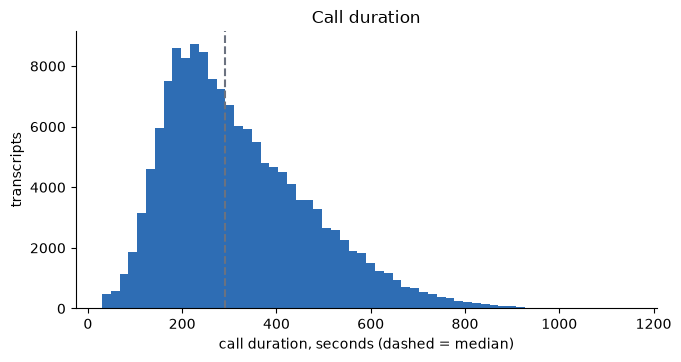

In [6]:
def duration_by(frame: pd.DataFrame, group: str) -> pd.DataFrame:
    """Summarises call duration by group with a 95% half-width for the mean.

    Exists so differences in duration between groups can be judged against their noise.

    Args:
        frame: Transcripts with a duration_seconds column.
        group: Column to group by.

    Returns:
        pd.DataFrame: transcripts with a duration, mean, median and 95% half-width of the mean, per group.
    """
    grouped = frame.groupby(group, observed=True, dropna=False)["duration_seconds"].agg(calls="count", mean="mean", median="median", std="std")
    grouped["ci_95"] = 1.96 * grouped["std"] / grouped["calls"] ** 0.5
    return grouped.drop(columns="std")


display(calls["duration_seconds"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99]).to_frame("duration_seconds"))
for group in ["main_topics", "audio_quality", "transcription_model", "detected_accent", "products"]:
    display(duration_by(calls, group).rename_axis(f"duration by {group}"))

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.hist(calls["duration_seconds"].dropna(), bins=60, color=BAR_COLOR)
ax.axvline(calls["duration_seconds"].median(), color=MUTED_COLOR, linestyle="--")
ax.set_xlabel("call duration, seconds (dashed = median)")
ax.set_ylabel("transcripts")
ax.set_title("Call duration")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

The **main topics** are six labels (`Transaccional`, `Producto`, `Queja`, `Técnico`, `Comercial`, `Retención`). Entities are counts of account numbers, dates and amounts plus a product
name. Duration is right-skewed (median 290 s) and **missing for 14%** of transcripts. **Duration is the one column that clearly depends on a label: it is tied to the main topic**
(mean 220 s for `Transaccional`, 266 `Producto`, 361 `Técnico`, 434 `Queja`, 480 `Retención` and 539 `Comercial`, each +/-1-4 s), while audio quality, transcription model, accent and product
mentioned make no difference (all about 320 s).

## 4. The text: what is said, and do the labels agree with it?

In [7]:
inventory = line_inventory.to_frame("occurrences")
inventory["speaker"] = inventory.index.str.split(":").str[0]
inventory["share_of_speaker_lines_pct"] = inventory["occurrences"] / inventory.groupby("speaker")["occurrences"].transform("sum") * 100
display(pd.Series({
    "distinct lines of dialogue in the whole history": len(inventory),
    "  spoken by the customer": (inventory["speaker"] == "Cliente").sum(),
    "  spoken by the agent": (inventory["speaker"] == "Agente").sum(),
    "distinct full conversations (exact text)": calls["conversation_signature"].nunique(),
    "transcripts with an unfilled placeholder such as {monto} (%)": calls["has_unfilled_placeholder"].mean() * 100,
}, name="value").to_frame())
pd.set_option("display.max_colwidth", 120)
display(inventory[["occurrences", "share_of_speaker_lines_pct"]].round(1))
pd.reset_option("display.max_colwidth")

,value
distinct lines of dialogue in the whole history,12.00
spoken by the customer,6.00
spoken by the agent,6.00
distinct full conversations (exact text),546.00
transcripts with an unfilled placeholder such as {monto} (%),100.00


,occurrences,share_of_speaker_lines_pct
full_text,,
"Agente: Buenas tardes, claro que sí. Déjeme revisar esa información. Su saldo actual es {monto} {moneda} y su límite disponible es de {limite} {moneda}.",85910,31.30
"Cliente: Buenas tardes, necesito consultar el saldo de mi tarjeta de crédito.",85910,31.30
"Cliente: Hola, buenos días. Quisiera saber cuál es mi saldo actual en mi cuenta de ahorros.",85411,31.20
"Agente: Buenos días, con gusto le ayudo. Permítame un momento para verificar su saldo. Su saldo actual es de {monto} {moneda}.",85411,31.20
Cliente: ¿Y eso cuánto tiempo tarda?,25908,9.40
"Agente: No hay problema, que tenga buen día.",25823,9.40
Agente: Con gusto. ¿Hay algo más en lo que pueda ayudarle?,25766,9.40
"Agente: Claro, estoy para servirle.",25752,9.40
"Cliente: Entiendo, muchas gracias.",25735,9.40


In [8]:
calls["turns"] = calls["customer_turns"] + calls["agent_turns"]
calls["opening"] = np.select(
    [calls["opening_line"].str.contains("ahorros", na=False), calls["opening_line"].str.contains("tarjeta de crédito", na=False)],
    ["asks the savings balance", "asks the credit card balance"], default="other or none",
)
display(calls["opening"].value_counts().to_frame("transcripts").assign(share_pct=lambda t: t["transcripts"] / len(calls) * 100))
display(calls["turns"].value_counts().sort_index().to_frame("transcripts"))
display(pd.Series({
    "transcripts where the customer asks how long it takes ('¿Y eso cuánto tiempo tarda?') (%)": calls["asks_how_long"].mean() * 100,
    "transcripts where the agent asks the customer to wait ('Permítame un momento') (%)": calls["agent_asks_to_wait"].mean() * 100,
}, name="value").to_frame())
display(pd.crosstab(calls["opening"], calls["agent_asks_to_wait"]).rename_axis(index="opening", columns="agent asks to wait"))
display(calls.groupby("turns")[["words"]].agg(["mean", "min", "max"]))

,transcripts,share_pct
opening,,
asks the credit card balance,85910,50.15
asks the savings balance,85411,49.85


,transcripts
turns,
2,102744
4,34307
6,34270


,value
transcripts where the customer asks how long it takes ('¿Y eso cuánto tiempo tarda?') (%),13.83
transcripts where the agent asks the customer to wait ('Permítame un momento') (%),49.85


agent asks to wait,False,True
opening,,
asks the credit card balance,85910,0
asks the savings balance,0,85411


words        
       mean min max
turns              
2     36.50  36  37
4     50.25  45  57
6     64.00  54  77

In [9]:
def cramers_v(first: pd.Series, second: pd.Series) -> float:
    """Computes Cramer's V, the association between two categorical variables (0 = none, 1 = perfect).

    Exists to test whether two labelings of the same transcripts agree, without any statistics library.

    Args:
        first: First categorical variable.
        second: Second categorical variable, aligned to first; rows where either is missing are ignored.

    Returns:
        float: Cramer's V.
    """
    complete = pd.concat([first, second], axis=1).dropna()
    table = pd.crosstab(complete.iloc[:, 0], complete.iloc[:, 1]).to_numpy().astype(float)
    expected = table.sum(axis=1, keepdims=True) * table.sum(axis=0, keepdims=True) / table.sum()
    chi_square = ((table - expected) ** 2 / expected).sum()
    return float((chi_square / (table.sum() * (min(table.shape) - 1))) ** 0.5)


calls["duration_band"] = pd.qcut(calls["duration_seconds"], 4, labels=["shortest 25%", "25-50%", "50-75%", "longest 25%"])
CANDIDATES = ["main_topics", "opening", "turns", "asks_how_long", "products", "audio_quality", "transcription_model", "detected_accent", "duration_band"]
agreement = pd.DataFrame({
    first: {second: cramers_v(calls[first], calls[second]) if first != second else np.nan for second in CANDIDATES}
    for first in CANDIDATES
})
display(agreement.rename_axis(index="Cramer's V between labelings"))

,main_topics,opening,turns,asks_how_long,products,audio_quality,transcription_model,detected_accent,duration_band
Cramer's V between labelings,,,,,,,,,
main_topics,NaN,0.01,0.01,0.01,0.00,0.01,0.01,0.01,0.43
opening,0.01,NaN,0.00,0.00,0.00,0.01,0.00,0.00,0.01
turns,0.01,0.00,NaN,0.52,0.00,0.00,0.00,0.00,0.00
asks_how_long,0.01,0.00,0.52,NaN,0.00,0.00,0.00,0.00,0.01
products,0.00,0.00,0.00,0.00,NaN,0.00,0.00,0.00,0.00
audio_quality,0.01,0.01,0.00,0.00,0.00,NaN,0.01,0.01,0.01
transcription_model,0.01,0.00,0.00,0.00,0.00,0.01,NaN,0.00,0.00
detected_accent,0.01,0.00,0.00,0.00,0.00,0.01,0.00,NaN,0.00
duration_band,0.43,0.01,0.00,0.01,0.00,0.01,0.00,0.00,NaN


The whole history contains only **12 distinct lines of dialogue** (6 by the customer, 6 by the agent), and **every conversation starts by asking for a balance** (savings account or credit card).
There are no complaints, technical problems or retention conversations in the text, although `main_topics` labels 17% of the transcripts `Queja`, 15% `Técnico` and 3% `Retención`. The
agent's reply carries unfilled placeholders (`{monto}`, `{moneda}`, `{limite}`), so no amounts appear. The associations are close to zero (0.00-0.01) between the text (opening request, number of turns), the topic and the other labels: **the topic labels do not agree with the text**. The two
exceptions are mechanical or structural: the number of turns goes with asking how long it takes (0.52, the question adds turns), and the **duration band goes with the main topic (0.43)**.

## 5. Grouping, iteration 1: rules on labels and text

In [10]:
calls["conversation_type"] = calls["opening"].str.replace("asks the ", "", regex=False) + " · " + calls["turns"].astype(str) + " turns"
calls["asks_how_long_label"] = np.where(calls["asks_how_long"], "asks how long it takes", "does not ask")


def profile_groups(frame: pd.DataFrame, group: str) -> pd.DataFrame:
    """Builds a profile of each group of transcripts: size, duration, turns, words and label mix.

    Exists so every candidate grouping is described on the same terms.

    Args:
        frame: Transcripts with the derived features.
        group: Column that defines the groups.

    Returns:
        pd.DataFrame: per group, transcripts, share, mean and median duration, mean turns and words, and the most frequent main topic with its share.
    """
    grouped = frame.groupby(group, observed=True)
    top_topic = grouped["main_topics"].agg(lambda s: s.value_counts().index[0])
    top_topic_share = grouped["main_topics"].agg(lambda s: s.value_counts(normalize=True).iloc[0] * 100)
    return pd.DataFrame({
        "transcripts": grouped.size(), "share_pct": grouped.size() / len(frame) * 100,
        "mean_duration_s": grouped["duration_seconds"].mean(), "median_duration_s": grouped["duration_seconds"].median(),
        "mean_turns": grouped["turns"].mean(), "mean_words": grouped["words"].mean(),
        "most frequent topic": top_topic, "its share_pct": top_topic_share,
    })


display(profile_groups(calls, "main_topics").rename_axis("groups by main topic (label)"))
display(profile_groups(calls, "conversation_type").rename_axis("groups by conversation type (text: what is asked and number of turns)"))
display(profile_groups(calls, "asks_how_long_label").rename_axis("groups by whether the customer asks how long it takes (text)"))
display(pd.crosstab(calls["main_topics"], calls["conversation_type"], normalize="index").mul(100).rename_axis(index="topic", columns="% of the topic's transcripts by conversation type"))

,transcripts,share_pct,mean_duration_s,median_duration_s,mean_turns,mean_words,most frequent topic,its share_pct
groups by main topic (label),,,,,,,,
Comercial,13808,8.06,538.64,541.00,3.23,44.91,Comercial,100.00
Producto,37658,21.98,266.19,262.00,3.20,44.76,Producto,100.00
Queja,29198,17.04,434.36,430.00,3.19,44.70,Queja,100.00
Retención,5180,3.02,479.98,479.00,3.21,44.85,Retención,100.00
Transaccional,59786,34.90,220.29,204.00,3.20,44.76,Transaccional,100.00
Técnico,25691,15.00,360.77,361.00,3.19,44.68,Técnico,100.00


,transcripts,share_pct,mean_duration_s,median_duration_s,mean_turns,mean_words,most frequent topic,its share_pct
groups by conversation type (text: what is asked and number of turns),,,,,,,,
credit card balance · 2 turns,51555,30.09,321.95,291.00,2.00,36.00,Transaccional,34.71
credit card balance · 4 turns,17197,10.04,322.25,292.00,4.00,49.74,Transaccional,35.22
credit card balance · 6 turns,17158,10.02,322.13,290.00,6.00,63.46,Transaccional,34.88
savings balance · 2 turns,51189,29.88,320.93,290.00,2.00,37.00,Transaccional,35.17
savings balance · 4 turns,17110,9.99,319.66,288.00,4.00,50.77,Transaccional,34.19
savings balance · 6 turns,17112,9.99,321.95,291.00,6.00,64.54,Transaccional,35.05


,transcripts,share_pct,mean_duration_s,median_duration_s,mean_turns,mean_words,most frequent topic,its share_pct
groups by whether the customer asks how long it takes (text),,,,,,,,
asks how long it takes,23697,13.83,323.47,292.00,5.27,58.52,Transaccional,34.32
does not ask,147624,86.17,321.14,290.00,2.87,42.54,Transaccional,34.99


% of the topic's transcripts by conversation type,credit card balance · 2 turns,credit card balance · 4 turns,credit card balance · 6 turns,savings balance · 2 turns,savings balance · 4 turns,savings balance · 6 turns
topic,,,,,,
Comercial,30.35,10.16,10.49,28.90,9.99,10.11
Producto,29.65,10.07,9.89,30.18,10.26,9.94
Queja,30.53,9.91,9.98,29.72,9.87,9.99
Retención,30.12,10.10,10.58,29.56,9.85,9.81
Transaccional,29.93,10.13,10.01,30.11,9.78,10.03
Técnico,30.47,9.83,9.88,29.67,10.22,9.93


Two groupings are available today, and they capture **different things**:

- The **label grouping** (`main_topics`, six groups) is **not visible in the text** (same 3.2 turns and 44.8 words in every topic, and the same mix of conversations) but it **is visible in duration**:
  `Comercial` (539 s), `Retención` (480 s) and `Queja` (434 s) are the longest, `Transaccional` (220 s) the shortest.
- The **text grouping** finds real structure (2 opening requests x 3 lengths, plus a subgroup that asks how long it takes), but it describes only balance inquiries and **has no relation to duration or to any label**
  (all conversation types last about 320 s).

## 6. Grouping, iteration 2: an unsupervised clustering check

In [11]:
def kmeans(matrix: np.ndarray, clusters: int, seed: int, iterations: int = 100) -> tuple[np.ndarray, float]:
    """Runs k-means with k-means++ initialisation.

    Exists to test, without a machine learning library, whether the numeric features separate into stable groups.

    Args:
        matrix: Standardised feature matrix, one row per transcript.
        clusters: Number of clusters.
        seed: Random seed for the initialisation.
        iterations: Maximum number of assignment and update rounds.

    Returns:
        tuple: (cluster label per row, inertia, the sum of squared distances to the assigned centre).
    """
    generator = np.random.default_rng(seed)
    centres = matrix[[generator.integers(len(matrix))]]
    for _ in range(clusters - 1):
        distance = ((matrix[:, None, :] - centres[None, :, :]) ** 2).sum(axis=2).min(axis=1)
        centres = np.vstack([centres, matrix[generator.choice(len(matrix), p=distance / distance.sum())]])
    labels = np.zeros(len(matrix), dtype=int)
    for _ in range(iterations):
        new_labels = ((matrix[:, None, :] - centres[None, :, :]) ** 2).sum(axis=2).argmin(axis=1)
        if np.array_equal(new_labels, labels):
            break
        labels = new_labels
        centres = np.vstack([matrix[labels == k].mean(axis=0) if (labels == k).any() else centres[k] for k in range(clusters)])
    return labels, float(((matrix - centres[labels]) ** 2).sum())


def count_pairs(counts: np.ndarray) -> np.ndarray:
    """Counts the pairs that can be formed from each count (n choose 2).

    Exists as the building block of the adjusted Rand index.

    Args:
        counts: Non-negative counts.

    Returns:
        np.ndarray: counts * (counts - 1) / 2, elementwise.
    """
    return counts * (counts - 1) / 2


def adjusted_rand_index(first: np.ndarray, second: np.ndarray) -> float:
    """Measures how similar two clusterings are (1 = identical, 0 = what chance gives).

    Exists to test whether clusters are stable across random starts.

    Args:
        first: Cluster labels of the first run.
        second: Cluster labels of the second run, for the same rows.

    Returns:
        float: adjusted Rand index.
    """
    table = pd.crosstab(first, second).to_numpy().astype(float)
    sum_cells, sum_rows, sum_columns = count_pairs(table).sum(), count_pairs(table.sum(axis=1)).sum(), count_pairs(table.sum(axis=0)).sum()
    expected = sum_rows * sum_columns / count_pairs(table.sum())
    return float((sum_cells - expected) / ((sum_rows + sum_columns) / 2 - expected))


NUMERIC_FEATURES = ["duration_seconds", "accent_confidence", "turns", "words", "account_numbers", "dates", "amounts"]
complete = calls.dropna(subset=NUMERIC_FEATURES).reset_index(drop=True)
matrix = ((complete[NUMERIC_FEATURES] - complete[NUMERIC_FEATURES].mean()) / complete[NUMERIC_FEATURES].std()).to_numpy()
rng = np.random.default_rng(0)
subset = rng.choice(len(matrix), size=min(40_000, len(matrix)), replace=False)
display(pd.Series({"transcripts with every numeric feature": len(complete), "used for the clustering check (random subset)": len(subset)}, name="value").to_frame())

rows = []
for k in [2, 3, 4, 5, 6, 8]:
    runs = [kmeans(matrix[subset], k, seed) for seed in range(3)]
    total = ((matrix[subset] - matrix[subset].mean(axis=0)) ** 2).sum()
    rows.append({
        "clusters": k, "share of variance explained (%)": (1 - runs[0][1] / total) * 100,
        "stability: mean adjusted Rand between 3 random starts": np.mean([adjusted_rand_index(runs[i][0], runs[j][0]) for i in range(3) for j in range(i + 1, 3)]),
    })
display(pd.DataFrame(rows).set_index("clusters"))

,value
transcripts with every numeric feature,119245
used for the clustering check (random subset),40000


,share of variance explained (%),stability: mean adjusted Rand between 3 random starts
clusters,,
2,23.64,1.00
3,30.49,0.46
4,34.45,0.32
5,41.44,0.37
6,44.81,0.36
8,50.64,0.41


In [12]:
K_TO_PROFILE = 4
labels, _ = kmeans(matrix[subset], K_TO_PROFILE, seed=0)
clustered = complete.iloc[subset].assign(cluster=labels)
display(clustered.groupby("cluster")[NUMERIC_FEATURES].mean().assign(transcripts=clustered.groupby("cluster").size()).rename_axis(f"profile of the {K_TO_PROFILE} clusters (means)"))
display(pd.crosstab(clustered["cluster"], clustered["main_topics"], normalize="index").mul(100).rename_axis(index="cluster", columns="% of the cluster by main topic"))
display(pd.Series({
    "Cramer's V: cluster vs main topic": cramers_v(clustered["cluster"].astype(str), clustered["main_topics"]),
    "Cramer's V: cluster vs conversation type": cramers_v(clustered["cluster"].astype(str), clustered["conversation_type"]),
}, name="value").to_frame())

,duration_seconds,accent_confidence,turns,words,account_numbers,dates,amounts,transcripts
profile of the 4 clusters (means),,,,,,,,
0,320.62,0.85,2.06,36.85,0.32,0.50,0.99,12341
1,321.13,0.85,5.04,57.65,1.65,0.52,0.98,7764
2,320.97,0.89,2.06,36.82,1.68,0.51,1.01,12302
3,322.38,0.90,5.07,57.72,0.35,0.49,1.03,7593


% of the cluster by main topic,Comercial,Producto,Queja,Retención,Transaccional,Técnico
cluster,,,,,,
0,7.79,21.87,16.94,3.03,35.36,15.01
1,7.86,21.87,17.72,3.04,34.47,15.04
2,8.06,21.83,16.86,3.00,34.90,15.35
3,8.18,21.57,17.53,3.29,35.14,14.29


,value
Cramer's V: cluster vs main topic,0.01
Cramer's V: cluster vs conversation type,0.56


The numeric features hold **one stable split and nothing else**. With 2 clusters the split is perfectly repeatable across random starts (adjusted Rand 1.00) and explains 23.6% of the variance,
but it separates **short from long text** (2 turns against 4-6 turns), not topics or durations. From 3 clusters on, the groups are **unstable** (adjusted Rand 0.32-0.46) and the variance explained rises
steadily with no elbow (30% to 51%), which is what a continuum looks like. The 4 clusters profiled differ only in turns, words and account numbers, and match the text types (Cramer's V 0.56),
not the topic (0.01) or the duration (about 321 s in every cluster). **A first unsupervised pass on these features does not find the topic structure that duration reveals**: topic has to be used as a label, not discovered.

## 7. Do the groups, or the call itself, relate to how customers rate it?

Only the transcripts whose interaction has a survey can be used (about a third). The outcomes are the **rating** (CSAT, scale 1-4), and the density of the reasons
customers give for low ratings: **waiting time**, **problem not resolved** and **unclear explanation**, per 100 surveys. If the length of the call, a request about time, or the type of
conversation caused waiting or unresolved problems, these would differ between groups.

In [13]:
linked = calls.merge(surveys.drop(columns=["customer_id", "agent_id"]), on="interaction_id", how="inner")
for reason in REASONS:
    linked[f"is_{reason.replace(' ', '_')}"] = linked["theme"] == reason
csat = linked[linked["survey_type"] == "CSAT"]
display(pd.Series({
    "transcripts linked to a survey": len(linked), "  of which CSAT": len(csat),
    "mean CSAT of the linked transcripts": csat["main_score"].mean(),
    "mean CSAT of all surveys": surveys.loc[surveys["survey_type"] == "CSAT", "main_score"].mean(),
    "linked surveys with a waiting-time comment per 100": linked["is_waiting_time"].mean() * 100,
    "linked surveys with a problem-not-resolved comment per 100": linked["is_problem_not_resolved"].mean() * 100,
    "linked surveys with an unclear-explanation comment per 100": linked["is_unclear_explanation"].mean() * 100,
}, name="value").to_frame())


def outcomes_by_group(frame: pd.DataFrame, csat_frame: pd.DataFrame, group: str) -> pd.DataFrame:
    """Computes CSAT and the density of each reason per group, with 95% half-widths.

    Exists so every grouping of the transcripts is compared on the same outcomes.

    Args:
        frame: Linked transcripts and surveys (all survey types).
        csat_frame: The CSAT subset of frame.
        group: Column that defines the groups.

    Returns:
        pd.DataFrame: per group, surveys, mean CSAT (+/-) and the density per 100 surveys of each reason (+/-).
    """
    csat_stats = csat_frame.groupby(group, observed=True)["main_score"].agg(["size", "mean", "std"])
    result = pd.DataFrame({"surveys": frame.groupby(group, observed=True).size(), "mean_CSAT": csat_stats["mean"],
                           "CSAT_+/-": 1.96 * csat_stats["std"] / csat_stats["size"] ** 0.5})
    for reason in REASONS:
        column = f"is_{reason.replace(' ', '_')}"
        share = frame.groupby(group, observed=True)[column].mean()
        result[f"{reason} per 100"] = share * 100
        result[f"{reason} +/-"] = 1.96 * (share * (1 - share) / result["surveys"]) ** 0.5 * 100
    return result


for group in ["main_topics", "conversation_type", "asks_how_long_label", "agent_asks_to_wait", "duration_band", "audio_quality", "transcription_model"]:
    display(outcomes_by_group(linked, csat, group).rename_axis(f"outcomes by {group}"))

,value
transcripts linked to a survey,"53,090.00"
of which CSAT,"31,956.00"
mean CSAT of the linked transcripts,2.77
mean CSAT of all surveys,2.77
linked surveys with a waiting-time comment per 100,12.78
linked surveys with a problem-not-resolved comment per 100,12.61
linked surveys with an unclear-explanation comment per 100,6.19


,surveys,mean_CSAT,CSAT_+/-,waiting time per 100,waiting time +/-,problem not resolved per 100,problem not resolved +/-,unclear explanation per 100,unclear explanation +/-
outcomes by main_topics,,,,,,,,,
Comercial,4314,2.67,0.03,13.61,1.02,13.07,1.01,6.86,0.75
Producto,11621,2.89,0.01,11.82,0.59,11.99,0.59,5.73,0.42
Queja,8953,2.44,0.02,14.83,0.74,13.96,0.72,6.87,0.52
Retención,1591,2.60,0.05,15.02,1.76,13.89,1.70,5.97,1.16
Transaccional,18707,2.91,0.01,11.74,0.46,12.11,0.47,5.92,0.34
Técnico,7904,2.69,0.02,13.40,0.75,12.66,0.73,6.44,0.54


,surveys,mean_CSAT,CSAT_+/-,waiting time per 100,waiting time +/-,problem not resolved per 100,problem not resolved +/-,unclear explanation per 100,unclear explanation +/-
outcomes by conversation_type,,,,,,,,,
credit card balance · 2 turns,15963,2.77,0.01,12.60,0.51,12.61,0.51,5.96,0.37
credit card balance · 4 turns,5457,2.76,0.02,13.32,0.90,13.25,0.90,6.38,0.65
credit card balance · 6 turns,5342,2.75,0.02,13.12,0.91,12.50,0.89,6.16,0.64
savings balance · 2 turns,15814,2.77,0.01,12.86,0.52,12.12,0.51,6.36,0.38
savings balance · 4 turns,5260,2.76,0.02,12.72,0.90,12.81,0.90,6.79,0.68
savings balance · 6 turns,5254,2.75,0.02,12.20,0.88,13.32,0.92,5.67,0.63


,surveys,mean_CSAT,CSAT_+/-,waiting time per 100,waiting time +/-,problem not resolved per 100,problem not resolved +/-,unclear explanation per 100,unclear explanation +/-
outcomes by asks_how_long_label,,,,,,,,,
asks how long it takes,7413,2.76,0.02,12.55,0.75,12.82,0.76,5.81,0.53
does not ask,45677,2.77,0.01,12.81,0.31,12.58,0.30,6.25,0.22


,surveys,mean_CSAT,CSAT_+/-,waiting time per 100,waiting time +/-,problem not resolved per 100,problem not resolved +/-,unclear explanation per 100,unclear explanation +/-
outcomes by agent_asks_to_wait,,,,,,,,,
False,26762,2.77,0.01,12.85,0.40,12.72,0.40,6.08,0.29
True,26328,2.77,0.01,12.70,0.40,12.50,0.40,6.31,0.29


,surveys,mean_CSAT,CSAT_+/-,waiting time per 100,waiting time +/-,problem not resolved per 100,problem not resolved +/-,unclear explanation per 100,unclear explanation +/-
outcomes by duration_band,,,,,,,,,
shortest 25%,11676,2.89,0.01,11.65,0.58,11.92,0.59,5.91,0.43
25-50%,11227,2.85,0.02,12.20,0.61,12.32,0.61,6.06,0.44
50-75%,11450,2.72,0.02,12.59,0.61,13.02,0.62,6.43,0.45
longest 25%,11310,2.60,0.02,14.16,0.64,13.24,0.62,6.67,0.46


,surveys,mean_CSAT,CSAT_+/-,waiting time per 100,waiting time +/-,problem not resolved per 100,problem not resolved +/-,unclear explanation per 100,unclear explanation +/-
outcomes by audio_quality,,,,,,,,,
High,35621,2.76,0.01,12.67,0.35,12.77,0.35,6.25,0.25
Low,2407,2.75,0.04,11.76,1.29,11.72,1.28,6.56,0.99
Medium,12363,2.77,0.02,13.04,0.59,12.55,0.58,5.97,0.42


,surveys,mean_CSAT,CSAT_+/-,waiting time per 100,waiting time +/-,problem not resolved per 100,problem not resolved +/-,unclear explanation per 100,unclear explanation +/-
outcomes by transcription_model,,,,,,,,,
AWS Transcribe,13309,2.76,0.02,12.86,0.57,12.56,0.56,5.77,0.40
Azure Speech,13169,2.78,0.02,12.64,0.57,12.98,0.57,6.14,0.41
Google STT,13224,2.77,0.02,13.12,0.58,12.67,0.57,6.14,0.41
Whisper v3,13388,2.76,0.02,12.50,0.56,12.25,0.56,6.72,0.42


,pairs,spearman,ci_low,ci_high
Spearman with call duration,,,,
CSAT,"27,511.00",-0.16,-0.17,-0.15
waiting time comment,"45,663.00",0.03,0.02,0.04
problem not resolved comment,"45,663.00",0.01,0.00,0.02
unclear explanation comment,"45,663.00",0.01,0.00,0.02


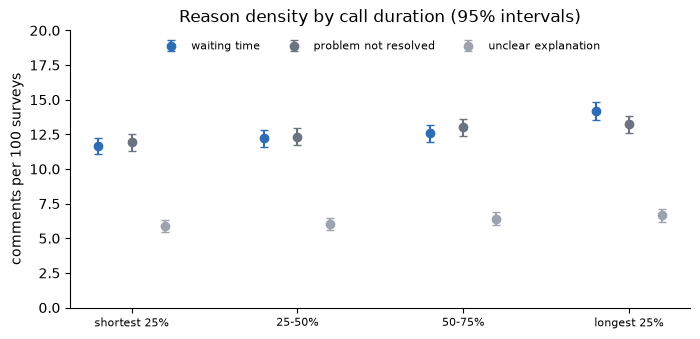

In [14]:
def spearman_with_interval(x: pd.Series, y: pd.Series) -> pd.Series:
    """Computes a Spearman rank correlation with an approximate 95% interval (Fisher z).

    Exists so every relationship is reported with its uncertainty.

    Args:
        x: First variable.
        y: Second variable, aligned to x.

    Returns:
        pd.Series: number of pairs, correlation and the lower and upper 95% limits.
    """
    frame = pd.concat([x, y], axis=1).dropna()
    rho = frame.iloc[:, 0].rank().corr(frame.iloc[:, 1].rank())
    half_width = 1.96 / np.sqrt(len(frame) - 3)
    return pd.Series({"pairs": len(frame), "spearman": rho, "ci_low": np.tanh(np.arctanh(rho) - half_width), "ci_high": np.tanh(np.arctanh(rho) + half_width)})


duration_tests = {"CSAT": spearman_with_interval(csat["duration_seconds"], csat["main_score"])}
for reason in REASONS:
    duration_tests[f"{reason} comment"] = spearman_with_interval(linked["duration_seconds"], linked[f"is_{reason.replace(' ', '_')}"].astype(float))
display(pd.DataFrame(duration_tests).T.rename_axis("Spearman with call duration"))

fig, ax = plt.subplots(figsize=(8, 3.6))
by_duration = outcomes_by_group(linked, csat, "duration_band")
positions = np.arange(len(by_duration))
for offset, reason, color in zip([-0.2, 0, 0.2], REASONS, [BAR_COLOR, MUTED_COLOR, "#9CA3AF"]):
    ax.errorbar(positions + offset, by_duration[f"{reason} per 100"], yerr=by_duration[f"{reason} +/-"], fmt="o", color=color, ecolor=color, capsize=3, label=reason)
ax.set_xticks(positions)
ax.set_xticklabels(by_duration.index, fontsize=8)
ax.set_ylim(0, 20)
ax.set_ylabel("comments per 100 surveys")
ax.set_title("Reason density by call duration (95% intervals)")
ax.legend(frameon=False, fontsize=8, ncol=3, loc="upper center")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

### Where the call time goes

In [15]:
timed = calls.dropna(subset=["duration_seconds"])
time_by_topic = timed.groupby("main_topics").agg(calls=("transcript_id", "size"), mean_duration_s=("duration_seconds", "mean"), total_hours=("duration_seconds", "sum"))
time_by_topic["total_hours"] = time_by_topic["total_hours"] / 3600
time_by_topic["share_of_calls_pct"] = time_by_topic["calls"] / time_by_topic["calls"].sum() * 100
time_by_topic["share_of_call_time_pct"] = time_by_topic["total_hours"] / time_by_topic["total_hours"].sum() * 100
time_by_topic["call time vs call count"] = time_by_topic["share_of_call_time_pct"] / time_by_topic["share_of_calls_pct"]
display(time_by_topic.sort_values("share_of_call_time_pct", ascending=False).rename_axis("call time by main topic (calls with a duration)"))
display(pd.Series({"calls with a duration": len(timed), "total call time, hours": time_by_topic["total_hours"].sum()}, name="value").to_frame())

,calls,mean_duration_s,total_hours,share_of_calls_pct,share_of_call_time_pct,call time vs call count
call time by main topic (calls with a duration),,,,,,
Transaccional,51452,220.29,"3,148.45",34.93,23.94,0.69
Queja,25137,434.36,"3,032.91",17.07,23.06,1.35
Producto,32287,266.19,"2,387.37",21.92,18.15,0.83
Técnico,22095,360.77,"2,214.24",15.00,16.84,1.12
Comercial,11877,538.64,"1,777.06",8.06,13.51,1.68
Retención,4444,479.98,592.51,3.02,4.50,1.49


,value
calls with a duration,"147,292.00"
"total call time, hours","13,152.56"


### Is it the topic or the duration?

In [16]:
csat = linked[linked["survey_type"] == "CSAT"].copy()
csat["duration_within_topic"] = csat.groupby("main_topics")["duration_seconds"].transform(lambda s: pd.qcut(s, 3, labels=["shorter", "middle", "longer"]))
by_topic_and_length = csat.pivot_table(index="main_topics", columns="duration_within_topic", values="main_score", aggfunc=["mean", "size"], observed=True)
display(by_topic_and_length.rename_axis(index="CSAT by topic and by call length within the topic (terciles of that topic's own durations)"))

by_topic_and_band = csat.pivot_table(index="main_topics", columns="duration_band", values="main_score", aggfunc=["mean", "size"], observed=True)
display(by_topic_and_band.rename_axis(index="CSAT by topic and by overall duration band"))

within_topic = pd.DataFrame({topic: spearman_with_interval(group["duration_seconds"], group["main_score"]) for topic, group in csat.groupby("main_topics")}).T
display(within_topic.rename_axis("Spearman between duration and CSAT, inside each topic"))

mean                  size              
duration_within_topic                              shorter middle longer shorter middle longer
CSAT by topic and by call length within the top...                                            
Comercial                                             2.66   2.67   2.67     728    723    726
Producto                                              2.89   2.89   2.90    1991   1971   1966
Queja                                                 2.44   2.43   2.47    1570   1562   1563
Retención                                             2.60   2.57   2.61     264    262    262
Transaccional                                         2.92   2.92   2.89    3294   3240   3214
Técnico                                               2.70   2.68   2.68    1404   1384   1387

mean                                   size                          
duration_band                              shortest 25% 25-50% 50-75% longest 25% shortest 25% 25-50% 50-75% longest 25%
CSAT by topic and by overall duration band                                                                              
Comercial                                          2.33   2.78   2.67        2.67           36     85    349        1707
Producto                                           2.88   2.89   2.90        2.92         1516   2263   1845         304
Queja                                              2.46   2.45   2.42        2.45          178    461   1541        2515
Retención                                          2.55   2.64   2.58        2.60           29     45    185         529
Transaccional                                      2.92   2.92   2.88        2.76         4921   3215   1179         433
Técnico                                            2.67   2.71   2.69        2.69          320    721   1861        1273

,pairs,spearman,ci_low,ci_high
"Spearman between duration and CSAT, inside each topic",,,,
Comercial,"2,177.00",0.01,-0.03,0.06
Producto,"5,928.00",0.01,-0.01,0.04
Queja,"4,695.00",0.02,-0.01,0.04
Retención,788.00,0.01,-0.06,0.08
Transaccional,"9,748.00",-0.03,-0.05,-0.01
Técnico,"4,175.00",0.00,-0.03,0.03


### Which topics generate the waiting and unresolved comments?

,surveys,share of all waiting comments (%),share of all unresolved comments (%),share of all unclear comments (%),share of surveys (%),waiting over-representation,unresolved over-representation
main_topics,,,,,,,
Retención,1591,3.52,3.30,2.89,3.00,1.18,1.10
Queja,8953,19.58,18.67,18.70,16.86,1.16,1.11
Comercial,4314,8.65,8.42,9.00,8.13,1.06,1.04
Técnico,7904,15.61,14.95,15.48,14.89,1.05,1.00
Producto,11621,20.26,20.81,20.26,21.89,0.93,0.95
Transaccional,18707,32.38,33.85,33.67,35.24,0.92,0.96


,mean CSAT,CSAT gap vs Transaccional,waiting comments per 100,excess waiting per 100 vs Transaccional,problem not resolved per 100,excess not resolved per 100 vs Transaccional
main_topics,,,,,,
Queja,2.44,-0.47,14.83,3.09,13.96,1.85
Retención,2.60,-0.32,15.02,3.28,13.89,1.78
Comercial,2.67,-0.24,13.61,1.87,13.07,0.96
Técnico,2.69,-0.22,13.40,1.66,12.66,0.55
Producto,2.89,-0.02,11.82,0.08,11.99,-0.13
Transaccional,2.91,0.00,11.74,0.00,12.11,0.00


,surveys,mean_CSAT,CSAT_+/-,waiting time per 100,waiting time +/-,problem not resolved per 100,problem not resolved +/-
outcomes by products,,,,,,,
Cuenta Ahorro,15877,2.77,0.01,12.78,0.52,12.68,0.52
Tarjeta Crédito,15987,2.77,0.01,12.89,0.52,12.30,0.51
none mentioned,15848,2.76,0.01,12.52,0.52,12.61,0.52


,surveys,mean_CSAT,CSAT_+/-,waiting time per 100,waiting time +/-,problem not resolved per 100,problem not resolved +/-
outcomes by account_numbers,,,,,,,
0.00,15886,2.76,0.01,12.71,0.52,12.22,0.51
1.00,15759,2.77,0.01,12.90,0.52,12.61,0.52
2.00,16067,2.77,0.01,12.58,0.51,12.76,0.52


,surveys,mean_CSAT,CSAT_+/-,waiting time per 100,waiting time +/-,problem not resolved per 100,problem not resolved +/-
outcomes by dates,,,,,,,
0.00,23798,2.76,0.01,12.88,0.43,12.69,0.42
1.00,23914,2.77,0.01,12.57,0.42,12.37,0.42


,surveys,mean_CSAT,CSAT_+/-,waiting time per 100,waiting time +/-,problem not resolved per 100,problem not resolved +/-
outcomes by amounts,,,,,,,
0.00,15762,2.77,0.01,12.83,0.52,12.50,0.52
1.00,15968,2.76,0.01,12.75,0.52,12.77,0.52
2.00,15982,2.78,0.01,12.61,0.51,12.32,0.51


,surveys,mean_CSAT,CSAT_+/-,waiting time per 100,waiting time +/-,problem not resolved per 100,problem not resolved +/-
outcomes by detected_accent,,,,,,,
argentine,6844,2.78,0.02,12.64,0.79,12.51,0.78
colombian,9999,2.77,0.02,12.70,0.65,13.03,0.66
mexican,16739,2.77,0.01,12.65,0.50,12.44,0.50


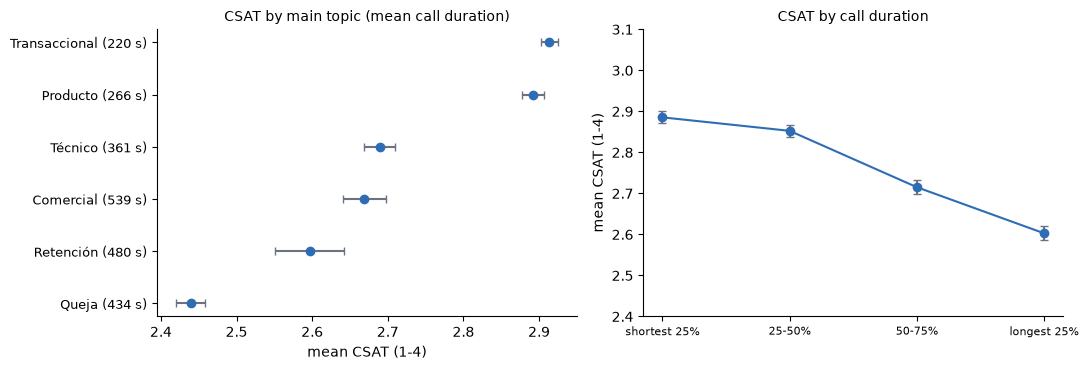

In [17]:
topic_comments = linked.groupby("main_topics").agg(
    surveys=("interaction_id", "size"), waiting=("is_waiting_time", "sum"), unresolved=("is_problem_not_resolved", "sum"), unclear=("is_unclear_explanation", "sum"))
for column in ["waiting", "unresolved", "unclear"]:
    topic_comments[f"share of all {column} comments (%)"] = topic_comments[column] / topic_comments[column].sum() * 100
topic_comments["share of surveys (%)"] = topic_comments["surveys"] / topic_comments["surveys"].sum() * 100
topic_comments["waiting over-representation"] = topic_comments["share of all waiting comments (%)"] / topic_comments["share of surveys (%)"]
topic_comments["unresolved over-representation"] = topic_comments["share of all unresolved comments (%)"] / topic_comments["share of surveys (%)"]
display(topic_comments.drop(columns=["waiting", "unresolved", "unclear"]).sort_values("waiting over-representation", ascending=False))

baseline_topic = "Transaccional"
outcomes = outcomes_by_group(linked, csat, "main_topics")
excess = pd.DataFrame({
    "mean CSAT": outcomes["mean_CSAT"], "CSAT gap vs Transaccional": outcomes["mean_CSAT"] - outcomes.loc[baseline_topic, "mean_CSAT"],
    "waiting comments per 100": outcomes["waiting time per 100"],
    "excess waiting per 100 vs Transaccional": outcomes["waiting time per 100"] - outcomes.loc[baseline_topic, "waiting time per 100"],
    "problem not resolved per 100": outcomes["problem not resolved per 100"],
    "excess not resolved per 100 vs Transaccional": outcomes["problem not resolved per 100"] - outcomes.loc[baseline_topic, "problem not resolved per 100"],
})
display(excess.sort_values("CSAT gap vs Transaccional"))

for group in ["products", "account_numbers", "dates", "amounts", "detected_accent"]:
    display(outcomes_by_group(linked, csat, group).rename_axis(f"outcomes by {group}")[["surveys", "mean_CSAT", "CSAT_+/-", "waiting time per 100", "waiting time +/-", "problem not resolved per 100", "problem not resolved +/-"]])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
ordered = outcomes.sort_values("mean_CSAT")
axes[0].errorbar(ordered["mean_CSAT"], range(len(ordered)), xerr=ordered["CSAT_+/-"], fmt="o", color=BAR_COLOR, ecolor=MUTED_COLOR, capsize=3)
axes[0].set_yticks(range(len(ordered)))
axes[0].set_yticklabels([f"{topic} ({time_by_topic.loc[topic, 'mean_duration_s']:.0f} s)" for topic in ordered.index], fontsize=9)
axes[0].set_xlabel("mean CSAT (1-4)")
axes[0].set_title("CSAT by main topic (mean call duration)", fontsize=10)
by_duration_csat = outcomes_by_group(linked, csat, "duration_band")
axes[1].errorbar(range(len(by_duration_csat)), by_duration_csat["mean_CSAT"], yerr=by_duration_csat["CSAT_+/-"], fmt="o-", color=BAR_COLOR, ecolor=MUTED_COLOR, capsize=3)
axes[1].set_xticks(range(len(by_duration_csat)))
axes[1].set_xticklabels(by_duration_csat.index, fontsize=8)
axes[1].set_ylim(2.4, 3.1)
axes[1].set_ylabel("mean CSAT (1-4)")
axes[1].set_title("CSAT by call duration", fontsize=10)
for axis in axes:
    axis.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**What relates to the customer's rating, and what does not.**

- **The main topic does**: CSAT is 2.91 for `Transaccional` and 2.89 for `Producto`, and 2.69 for `Técnico`, 2.67 for `Comercial`, 2.60 for `Retención` and **2.44 for `Queja`** (intervals +/-0.01-0.05). Customers
  who called about a complaint or retention also give more waiting-time comments (14.8 and 15.0 per 100 surveys against 11.7 for `Transaccional`) and more problem-not-resolved comments (14.0 and 13.9 against 12.1).
- **Call duration does too, across calls**: CSAT falls from 2.89 (shortest quarter) to 2.60 (longest), Spearman -0.16, and waiting-time comments rise from 11.7 to 14.2 per 100 surveys.
- **But it is the topic, not the length**: *inside* each topic the call length has no effect (CSAT of the shorter / middle / longer third of calls: `Queja` 2.44 / 2.43 / 2.47, `Comercial` 2.66 / 2.67 / 2.67, `Producto` 2.89 / 2.89 / 2.90;
  Spearman inside topics between 0.00 and 0.02, `Transaccional` -0.03). Longer calls are simply the topics that are longer and lower rated. (For the waiting-time comment a small length gradient does remain inside topics: see section 8.2.)
- **Nothing else does**: the text type (what is asked, number of turns), asking how long it takes, the agent asking the customer to wait, audio quality, transcription model, accent, product and entity counts all give
  CSAT of 2.75-2.78 and the same reason densities (differences inside the intervals).

**Where the time and the dissatisfaction concentrate.** `Queja` is 17.1% of the calls with a duration but **23.1% of the call time** (1.35x its share), `Comercial` 8.1% of the calls and 13.5% of the time (1.68x), `Retención` 3.0% and 4.5% (1.49x),
`Técnico` 15.0% and 16.8% (1.12x); `Transaccional` is 34.9% of the calls but only 23.9% of the time (0.69x). Total call time is 13,153 hours over the 3 years. `Queja` and `Retención` have the lowest CSAT (gaps of -0.47 and -0.32 against `Transaccional`)
and the largest excess of waiting-time (+3.1 and +3.3 per 100) and unresolved-problem comments (+1.9 and +1.8 per 100), but each topic's share of those comments is at most 1.2 times its share of the surveys.

## 8. Users whose survey complains about waiting time

**Focus.** The customers whose survey comment is one of the two waiting sentences (`Tardaron mucho en atenderme.` or `Tuve que esperar demasiado tiempo.`) and whose interaction has a transcript.
The question is what is different about **their calls**: the topic, the length, the conversation, the audio, the agent, the day, and the customer's **call history** (did they have to call again?).
The comparison group is every other linked survey.

In [18]:
linked["is_low_rating"] = linked["main_score"].isin([1, 2, 3])
linked["group"] = np.select(
    [linked["is_waiting_time"], linked["theme"].notna(), linked["is_low_rating"]],
    ["waiting-time complaint", "another stated reason", "rated 1-3, no reason"], default="rated above 3",
)
waiting = linked[linked["is_waiting_time"]]
rest = linked[~linked["is_waiting_time"]]
display(pd.Series({
    "linked surveys": len(linked),
    "surveys whose comment complains about waiting time": len(waiting),
    "  as % of linked surveys": len(waiting) / len(linked) * 100,
    "  distinct customers": waiting["customer_id"].nunique(),
    "  distinct agents": waiting["agent_id"].nunique(),
    "  of which CSAT / NPS / CES": " / ".join(str(int((waiting["survey_type"] == t).sum())) for t in ["CSAT", "NPS", "CES"]),
}, name="value").to_frame())
display(linked["group"].value_counts().to_frame("linked surveys"))

,value
linked surveys,53090
surveys whose comment complains about waiting time,6783
as % of linked surveys,12.78
distinct customers,6648
distinct agents,1089
of which CSAT / NPS / CES,5422 / 458 / 903


,linked surveys
group,
"rated 1-3, no reason",18585
rated above 3,17739
another stated reason,9983
waiting-time complaint,6783


### 8.1 Who are they? Feature by feature against everyone else

In [19]:
linked["weekday"] = linked["process_date"].dt.day_name()
linked["year"] = linked["process_date"].dt.year.astype(str)
linked["call_minutes"] = pd.cut(linked["duration_seconds"], [0, 180, 300, 420, 600, 2000], labels=["under 3 min", "3-5 min", "5-7 min", "7-10 min", "over 10 min"])
FEATURES = ["main_topics", "call_minutes", "duration_band", "opening", "turns", "asks_how_long", "agent_asks_to_wait", "audio_quality", "transcription_model",
            "detected_accent", "products", "account_numbers", "dates", "amounts", "weekday", "year", "send_channel", "survey_type"]


def compare_shares(frame: pd.DataFrame, flag: str, feature: str) -> pd.DataFrame:
    """Compares how often each level of a feature occurs among flagged rows and among the rest.

    Exists to find what distinguishes the calls of customers who complain about waiting, on identical terms for every feature.

    Args:
        frame: Linked transcripts and surveys carrying a boolean flag column.
        flag: Name of the boolean column that marks the group of interest.
        feature: Name of the categorical column to compare.

    Returns:
        pd.DataFrame: per level, share among flagged rows, share among the rest, the difference in points, its 95% half-width and the lift.
    """
    flagged, other = frame[frame[flag]], frame[~frame[flag]]
    share_flagged = flagged[feature].astype(str).value_counts(normalize=True)
    share_other = other[feature].astype(str).value_counts(normalize=True)
    levels = share_flagged.index.union(share_other.index)
    share_flagged, share_other = share_flagged.reindex(levels, fill_value=0), share_other.reindex(levels, fill_value=0)
    half_width = 1.96 * (share_flagged * (1 - share_flagged) / len(flagged) + share_other * (1 - share_other) / len(other)) ** 0.5
    return pd.DataFrame({
        "feature": feature, "level": levels, "waiting_complaint_pct": share_flagged.to_numpy() * 100, "others_pct": share_other.to_numpy() * 100,
        "difference_pts": (share_flagged - share_other).to_numpy() * 100, "ci_pts": half_width.to_numpy() * 100,
        "lift": (share_flagged / share_other).to_numpy(),
    })


comparison = pd.concat([compare_shares(linked, "is_waiting_time", feature) for feature in FEATURES], ignore_index=True)
comparison["difference_in_intervals"] = comparison["difference_pts"] / comparison["ci_pts"]
comparison["outside_noise"] = comparison["difference_in_intervals"].abs() > 1
display(pd.Series({
    "feature levels compared": len(comparison),
    "levels whose difference is outside its 95% interval": int(comparison["outside_noise"].sum()),
    "  expected by chance alone (5%)": len(comparison) * 0.05,
}, name="value").to_frame())
display(comparison[comparison["outside_noise"]].sort_values("difference_in_intervals", key=abs, ascending=False)
        [["feature", "level", "waiting_complaint_pct", "others_pct", "difference_pts", "ci_pts", "lift"]].reset_index(drop=True))

,value
feature levels compared,64.00
levels whose difference is outside its 95% interval,14.00
expected by chance alone (5%),3.20


,feature,level,waiting_complaint_pct,others_pct,difference_pts,ci_pts,lift
0,survey_type,NPS,6.75,33.26,-26.51,0.74,0.20
1,survey_type,CSAT,79.94,57.30,22.63,1.05,1.40
2,survey_type,CES,13.31,9.44,3.87,0.85,1.41
3,main_topics,Queja,19.58,16.47,3.11,1.00,1.19
4,duration_band,longest 25%,27.75,24.34,3.41,1.14,1.14
5,main_topics,Transaccional,32.38,35.66,-3.28,1.20,0.91
6,call_minutes,7-10 min,20.54,17.94,2.60,1.02,1.15
7,duration_band,shortest 25%,23.56,25.86,-2.30,1.09,0.91
8,call_minutes,under 3 min,16.25,18.01,-1.77,0.95,0.90
9,main_topics,Producto,20.26,22.13,-1.87,1.03,0.92


In [20]:
topic_view = comparison[comparison["feature"] == "main_topics"].set_index("level")[["waiting_complaint_pct", "others_pct", "difference_pts", "ci_pts", "lift"]]
display(topic_view.sort_values("lift", ascending=False).rename_axis("topic mix of the waiting-time complaints vs everyone else"))
minutes_view = comparison[comparison["feature"] == "call_minutes"].set_index("level")[["waiting_complaint_pct", "others_pct", "difference_pts", "ci_pts", "lift"]]
display(minutes_view.rename_axis("call length of the waiting-time complaints vs everyone else"))
display(pd.DataFrame({
    "waiting-time complaints": waiting["duration_seconds"].describe(),
    "everyone else": rest["duration_seconds"].describe(),
}).rename_axis("call duration, seconds"))

,waiting_complaint_pct,others_pct,difference_pts,ci_pts,lift
topic mix of the waiting-time complaints vs everyone else,,,,,
Retención,3.52,2.92,0.60,0.46,1.21
Queja,19.58,16.47,3.11,1.00,1.19
Comercial,8.65,8.05,0.61,0.71,1.08
Técnico,15.61,14.78,0.83,0.92,1.06
Producto,20.26,22.13,-1.87,1.03,0.92
Transaccional,32.38,35.66,-3.28,1.20,0.91


,waiting_complaint_pct,others_pct,difference_pts,ci_pts,lift
call length of the waiting-time complaints vs everyone else,,,,,
3-5 min,33.10,34.97,-1.87,1.20,0.95
5-7 min,23.61,23.50,0.11,1.08,1.00
7-10 min,20.54,17.94,2.60,1.02,1.15
over 10 min,6.50,5.57,0.93,0.62,1.17
under 3 min,16.25,18.01,-1.77,0.95,0.90


,waiting-time complaints,everyone else
"call duration, seconds",,
count,"5,773.00","39,890.00"
mean,332.88,318.64
std,157.92,152.69
min,30.00,30.00
25%,211.00,203.00
50%,304.00,288.00
75%,433.00,411.00
max,"1,124.00","1,151.00"


### 8.2 Is it the topic or the length? The waiting-complaint rate inside each topic

In [21]:
def rate_with_interval(frame: pd.DataFrame, group: list[str]) -> pd.DataFrame:
    """Computes the rate of waiting-time complaints per 100 surveys for each group, with a 95% half-width.

    Exists so the rate can be compared across topics and call lengths on identical terms.

    Args:
        frame: Linked transcripts and surveys with the is_waiting_time flag.
        group: Columns that define the groups.

    Returns:
        pd.DataFrame: surveys, waiting-time complaints per 100 surveys and the 95% half-width, per group.
    """
    grouped = frame["is_waiting_time"].groupby([frame[column] for column in group], observed=True).agg(["size", "mean"])
    half_width = 1.96 * (grouped["mean"] * (1 - grouped["mean"]) / grouped["size"]) ** 0.5
    return pd.DataFrame({"surveys": grouped["size"], "per_100": grouped["mean"] * 100, "+/-": half_width * 100})


linked["length_within_topic"] = linked.groupby("main_topics")["duration_seconds"].transform(lambda s: pd.qcut(s, 3, labels=["shorter", "middle", "longer"]))
by_topic_and_length = rate_with_interval(linked, ["main_topics", "length_within_topic"]).unstack("length_within_topic")
display(by_topic_and_length.rename_axis(index="waiting-time complaints per 100 surveys, by topic and by call length within the topic"))
display(rate_with_interval(linked, ["call_minutes"]).rename_axis("waiting-time complaints per 100 surveys, by call length"))

topic_rates = rate_with_interval(linked, ["main_topics"])
baseline_rate = topic_rates.loc["Transaccional", "per_100"] / 100
expected_at_baseline = topic_rates["surveys"] * baseline_rate
explained = pd.DataFrame({
    "surveys": topic_rates["surveys"], "waiting complaints": (topic_rates["per_100"] / 100 * topic_rates["surveys"]).round(),
    "expected at the Transaccional rate": expected_at_baseline.round(),
})
explained["excess linked to the topic"] = explained["waiting complaints"] - explained["expected at the Transaccional rate"]
display(explained.rename_axis("how many waiting-time complaints does the topic account for?"))
display(pd.Series({
    "waiting-time complaints": explained["waiting complaints"].sum(),
    "excess over the Transaccional rate (all topics)": explained["excess linked to the topic"].clip(lower=0).sum(),
    "  as % of all waiting-time complaints": explained["excess linked to the topic"].clip(lower=0).sum() / explained["waiting complaints"].sum() * 100,
}, name="value").to_frame())

surveys               per_100                   +/-              
length_within_topic                                shorter middle longer shorter middle longer shorter middle longer
waiting-time complaints per 100 surveys, by top...                                                                  
Comercial                                             1230   1229   1222   12.36  13.51  14.08    1.84   1.91   1.95
Producto                                              3331   3348   3309   11.56  11.59  11.51    1.09   1.08   1.09
Queja                                                 2571   2570   2569   14.00  14.59  15.18    1.34   1.36   1.39
Retención                                              457    449    453   14.88  16.70  14.13    3.26   3.45   3.21
Transaccional                                         5433   5305   5358   11.49  11.78  12.09    0.85   0.87   0.87
Técnico                                               2281   2276   2272   12.45  13.36  13.73    1.35   1.40   1.42

,surveys,per_100,+/-
"waiting-time complaints per 100 surveys, by call length",,,
under 3 min,8124,11.55,0.69
3-5 min,15861,12.05,0.51
5-7 min,10739,12.69,0.63
7-10 min,8343,14.22,0.75
over 10 min,2596,14.45,1.35


,surveys,waiting complaints,expected at the Transaccional rate,excess linked to the topic
how many waiting-time complaints does the topic account for?,,,,
Comercial,4314,587.00,506.00,81.00
Producto,11621,"1,374.00","1,364.00",10.00
Queja,8953,"1,328.00","1,051.00",277.00
Retención,1591,239.00,187.00,52.00
Transaccional,18707,"2,196.00","2,196.00",0.00
Técnico,7904,"1,059.00",928.00,131.00


,value
waiting-time complaints,"6,783.00"
excess over the Transaccional rate (all topics),551.00
as % of all waiting-time complaints,8.12


### 8.3 Did they have to call again? The customer's call history

In [22]:
DAY_MULTIPLIER = 10_000
customer_code = pd.factorize(calls["customer_id"])[0]
day_number = (calls["process_date"] - calls["process_date"].min()).dt.days.to_numpy()
keys = customer_code.astype(np.int64) * DAY_MULTIPLIER + day_number
sorted_keys = np.sort(keys)
calls["calls_in_previous_30_days"] = np.searchsorted(sorted_keys, keys, side="left") - np.searchsorted(sorted_keys, keys - 30, side="left")
calls["calls_in_next_30_days"] = np.searchsorted(sorted_keys, keys + 30, side="right") - np.searchsorted(sorted_keys, keys, side="right")
history = calls[["interaction_id", "calls_in_previous_30_days", "calls_in_next_30_days"]]
linked = linked.drop(columns=[c for c in history.columns if c != "interaction_id" and c in linked.columns]).merge(history, on="interaction_id", how="left")
follow_up_complete = linked["process_date"] <= calls["process_date"].max() - pd.Timedelta(days=30)
linked["called_before"] = linked["calls_in_previous_30_days"] > 0
linked["called_again"] = (linked["calls_in_next_30_days"] > 0).astype(float).where(follow_up_complete)

history_table = pd.DataFrame({
    "waiting-time complaints": [linked.loc[linked["is_waiting_time"], "calls_in_previous_30_days"].mean() , linked.loc[linked["is_waiting_time"], "called_before"].mean() * 100,
                                linked.loc[linked["is_waiting_time"], "called_again"].mean() * 100],
    "everyone else": [linked.loc[~linked["is_waiting_time"], "calls_in_previous_30_days"].mean(), linked.loc[~linked["is_waiting_time"], "called_before"].mean() * 100,
                      linked.loc[~linked["is_waiting_time"], "called_again"].mean() * 100],
}, index=["mean calls in the previous 30 days", "% who called in the previous 30 days", "% who called again in the next 30 days"])
display(history_table)
followed = linked[follow_up_complete].assign(called_again_label=lambda table: np.where(table["calls_in_next_30_days"] > 0, "called again", "did not call again"))
display(compare_shares(followed, "is_waiting_time", "called_again_label")
        .rename_axis("called again within 30 days (surveys with a complete 30-day follow-up)"))
display(rate_with_interval(linked.assign(previous_calls=linked["calls_in_previous_30_days"].clip(upper=2).astype(str)), ["previous_calls"])
        .rename_axis("waiting-time complaints per 100 surveys, by calls made in the previous 30 days (2 = two or more)"))
display(rate_with_interval(linked[follow_up_complete].assign(next_calls=linked["calls_in_next_30_days"].clip(upper=2).astype(str)), ["next_calls"])
        .rename_axis("waiting-time complaints per 100 surveys, by calls made in the next 30 days (2 = two or more)"))

,waiting-time complaints,everyone else
mean calls in the previous 30 days,0.04,0.03
% who called in the previous 30 days,3.39,3.15
% who called again in the next 30 days,3.23,3.23


,feature,level,waiting_complaint_pct,others_pct,difference_pts,ci_pts,lift
called again within 30 days (surveys with a complete 30-day follow-up),,,,,,,
0,called_again_label,did not call again,96.77,96.77,0.00,0.46,1.00
1,called_again_label,called again,3.23,3.23,-0.00,0.46,1.00


,surveys,per_100,+/-
"waiting-time complaints per 100 surveys, by calls made in the previous 30 days (2 = two or more)",,,
0,51401,12.75,0.29
1,1656,13.41,1.64
2,33,24.24,14.62


,surveys,per_100,+/-
"waiting-time complaints per 100 surveys, by calls made in the next 30 days (2 = two or more)",,,
0,49924,12.73,0.29
1,1637,12.71,1.61
2,29,13.79,12.55


### 8.4 Agents and repeat complainers

In [23]:
agent_waiting = linked.groupby("agent_id").agg(surveys=("interaction_id", "size"), waiting=("is_waiting_time", "sum"))
agent_waiting = agent_waiting[agent_waiting["surveys"] >= 30]
overall_rate = linked["is_waiting_time"].mean()
display(pd.Series({
    "agents with >= 30 linked surveys": len(agent_waiting), "linked surveys per agent (median)": agent_waiting["surveys"].median(),
    "overall waiting-time complaint rate (%)": overall_rate * 100,
    "spread of agents' rate, observed (points)": (agent_waiting["waiting"] / agent_waiting["surveys"]).std() * 100,
    "spread expected if agents were identical (points)": (overall_rate * (1 - overall_rate) / agent_waiting["surveys"]).mean() ** 0.5 * 100,
}, name="value").to_frame())

per_customer = linked.groupby("customer_id").agg(surveys=("interaction_id", "size"), waiting=("is_waiting_time", "sum"))
repeat_customers = per_customer[per_customer["surveys"] >= 2]
expected_two_or_more = (1 - (1 - overall_rate) ** repeat_customers["surveys"] - repeat_customers["surveys"] * overall_rate * (1 - overall_rate) ** (repeat_customers["surveys"] - 1)).mean()
display(pd.Series({
    "customers with 2 or more linked surveys": len(repeat_customers),
    "  with at least one waiting-time complaint (%)": (repeat_customers["waiting"] >= 1).mean() * 100,
    "  with two or more waiting-time complaints (%)": (repeat_customers["waiting"] >= 2).mean() * 100,
    "  two or more expected if independent (%)": expected_two_or_more * 100,
}, name="value").to_frame())

,value
agents with >= 30 linked surveys,"1,089.00"
linked surveys per agent (median),48.00
overall waiting-time complaint rate (%),12.78
"spread of agents' rate, observed (points)",4.79
spread expected if agents were identical (points),4.83


,value
customers with 2 or more linked surveys,"7,520.00"
with at least one waiting-time complaint (%),25.69
with two or more waiting-time complaints (%),1.76
two or more expected if independent (%),2.01


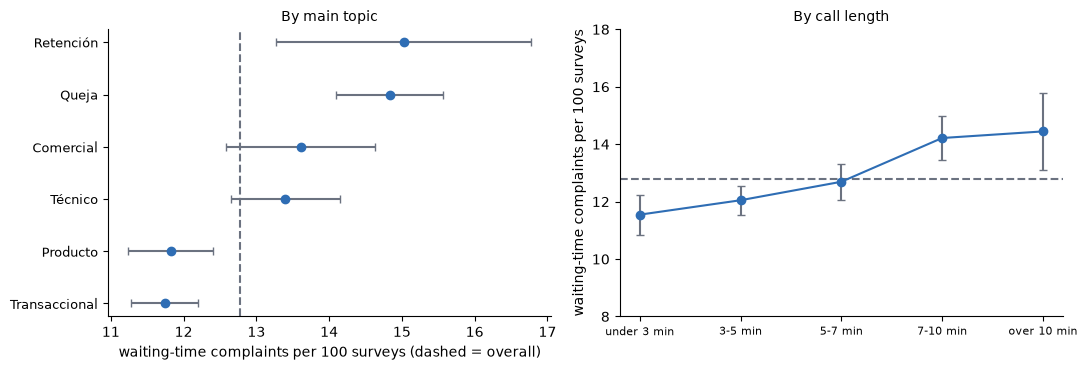

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
ordered_topics = topic_rates.sort_values("per_100")
axes[0].errorbar(ordered_topics["per_100"], range(len(ordered_topics)), xerr=ordered_topics["+/-"], fmt="o", color=BAR_COLOR, ecolor=MUTED_COLOR, capsize=3)
axes[0].axvline(overall_rate * 100, color=MUTED_COLOR, linestyle="--")
axes[0].set_yticks(range(len(ordered_topics)))
axes[0].set_yticklabels(ordered_topics.index, fontsize=9)
axes[0].set_xlabel("waiting-time complaints per 100 surveys (dashed = overall)")
axes[0].set_title("By main topic", fontsize=10)
minutes = rate_with_interval(linked, ["call_minutes"])
axes[1].errorbar(range(len(minutes)), minutes["per_100"], yerr=minutes["+/-"], fmt="o-", color=BAR_COLOR, ecolor=MUTED_COLOR, capsize=3)
axes[1].axhline(overall_rate * 100, color=MUTED_COLOR, linestyle="--")
axes[1].set_xticks(range(len(minutes)))
axes[1].set_xticklabels(minutes.index, fontsize=8)
axes[1].set_ylim(8, 18)
axes[1].set_ylabel("waiting-time complaints per 100 surveys")
axes[1].set_title("By call length", fontsize=10)
for axis in axes:
    axis.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Reading: the customers who complain about waiting have calls that look almost like everyone else's.** There are 6,783 such surveys (12.8% of the linked ones; 6,648 customers and 1,089 agents). Of 64 feature levels compared with everyone
else, only 14 fall outside their 95% interval (3.2 would be expected by chance), and they reduce to **two modest signals** plus a mechanical one:

- **Topic.** They are over-represented in `Queja` (19.6% against 16.5%, lift 1.19), `Retención` (3.5% against 2.9%, 1.21), and under-represented in `Transaccional` (32.4% against 35.7%) and `Producto` (20.3% against 22.1%).
- **Longer calls.** Median 304 s against 288 s. The rate of waiting-time complaints rises from **11.6 per 100 surveys for calls under 3 minutes to 14.2-14.5 for calls over 7 minutes**. Inside `Comercial`, `Queja` and `Técnico`, the longest third of calls has 1.2-1.7 more complaints
  per 100 surveys than the shortest third (for example `Queja` 14.0 / 14.6 / 15.2 and `Comercial` 12.4 / 13.5 / 14.1); `Producto` shows no gradient (11.6 / 11.6 / 11.5). So, unlike the rating, **the waiting complaint keeps a small length effect inside the topics**.
- The survey type differs (80% CSAT against 57%, 7% NPS against 33%), but that is **mechanical**: waiting comments only exist on ratings of 1-3, which are 89% of CSAT and CES surveys but 15% of NPS.

**What they do not have.** Nothing else separates them: audio quality, transcription model, accent, product or entities mentioned, the type of conversation, the customer asking how long it takes, the agent asking them to wait, the agent handling the call (spread of agents'
rate 4.79 points against 4.83 expected by chance). Nor did they have to **call again**: 3.4% had called in the previous 30 days (3.2% of the others) and 3.2% called again in the next 30 days (3.2%). Customers with two or more waiting complaints (1.76%) are no more than expected if independent (2.01%).

**How much do the observable signals explain?** If every topic complained about waiting at the `Transaccional` rate (11.7 per 100), there would be 6,232 waiting complaints instead of 6,783: the topic accounts for **551 (8.1%)**. About **92% of the waiting complaints occur at the baseline rate in every topic**,
with nothing in the transcript that marks them.

**Why this fits the data.** The complaint is about waiting to be attended (`Tardaron mucho en atenderme`, `Tuve que esperar demasiado tiempo`), which happens before or around the call, and the transcripts hold only what is said during it (duration is talk time, and the text is a balance-inquiry script).
The transcripts therefore carry no signature of who will complain about waiting; queue and hold times are what is missing.

## 9. Agents: roster stats, an AI-agent check, and do agent attributes relate to outcomes?

In [25]:
SERVICE_AGENTS_PATH = REPO_ROOT / "data" / "service_agents.csv"
agents = pd.read_csv(SERVICE_AGENTS_PATH, parse_dates=["hire_date"])
agents["tenure_years"] = (calls["process_date"].max() - agents["hire_date"]).dt.days / 365.25

schema = pd.DataFrame({"dtype": agents.dtypes.astype(str), "missing_pct": agents.isna().mean() * 100, "distinct": agents.nunique()})
display(schema)
display(pd.Series({
    "agents": len(agents),
    "duplicate agent_id": agents["agent_id"].duplicated().sum(),
    "duplicate employee_code": agents["employee_code"].duplicated().sum(),
    "duplicate email": agents["email"].duplicated().sum(),
    "agent_id present in the transcripts (%)": agents["agent_id"].isin(calls["agent_id"]).mean() * 100,
    "transcript agent_id present in the roster (%)": calls["agent_id"].isin(agents["agent_id"]).mean() * 100,
}, name="value").to_frame())

,dtype,missing_pct,distinct
agent_id,str,0.00,1200
employee_code,str,0.00,1187
first_name,str,0.00,444
last_name,str,0.00,975
email,str,0.00,1188
phone,str,5.75,1131
native_accent,str,0.00,3
country_of_origin,str,0.00,3
assigned_branch_id,str,30.58,833
agent_type,str,0.00,4


,value
agents,"1,200.00"
duplicate agent_id,0.00
duplicate employee_code,13.00
duplicate email,12.00
agent_id present in the transcripts (%),90.83
transcript agent_id present in the roster (%),100.00


### 9.1 Is any agent an AI agent?

In [26]:
AUTOMATION_PATTERN = r"bot|virtual|chatbot|asistente|automat|inteligencia artificial|\bIA\b|\bAI\b"
suspect_rows = agents[
    agents["email"].str.contains(AUTOMATION_PATTERN, case=False, na=False, regex=True)
    | agents["first_name"].str.contains(AUTOMATION_PATTERN, case=False, na=False, regex=True)
    | agents["last_name"].str.contains(AUTOMATION_PATTERN, case=False, na=False, regex=True)
    | agents["specialty"].str.contains(AUTOMATION_PATTERN, case=False, na=False, regex=True)
]
display(pd.Series({
    "distinct agent_type values": agents["agent_type"].nunique(),
    "agent_type values": ", ".join(sorted(agents["agent_type"].unique())),
    "agents with hire_date, native_accent and country_of_origin all present (i.e. modeled as a person)":
        agents[["hire_date", "native_accent", "country_of_origin"]].notna().all(axis=1).sum(),
    "email domains in use": ", ".join(sorted(agents["email"].str.split("@").str[1].unique())),
    "rows matching an automation keyword in name, email or specialty": len(suspect_rows),
}, name="value").to_frame())
display(agents["agent_type"].value_counts().to_frame("agents"))

,value
distinct agent_type values,4
agent_type values,"Digital, Hybrid, In-Person, Phone"
"agents with hire_date, native_accent and country_of_origin all present (i.e. modeled as a person)",1200
email domains in use,"bancogmail.com, bancohotmail.com, bancoicloud...."
"rows matching an automation keyword in name, email or specialty",0


,agents
agent_type,
Phone,588
Digital,251
In-Person,230
Hybrid,131


**No AI agent is registered.** `agent_type` has four values (`Phone`, `Digital`, `In-Person`, `Hybrid`) describing a **channel**, not an automation tier; there is no `Bot`, `Virtual` or
`AI` category. Every one of the 1,200 rows carries a human name, a hire date, a native accent and a country of origin, and no automation keyword appears in any name, email or
specialty. `Digital` (251 agents) means a human agent assigned to digital channels, not a bot.

### 9.2 Roster stats

In [27]:
for column in ["agent_type", "experience_level", "specialty", "agent_status", "work_shift", "native_accent", "languages"]:
    counts = agents[column].value_counts(dropna=False)
    display(pd.DataFrame({"agents": counts, "share_pct": counts / len(agents) * 100}).rename_axis(column))
display(agents[["avg_csat", "total_monthly_interactions", "tenure_years"]].describe())
display(pd.Series({"hire_date: earliest / latest": f"{agents['hire_date'].min().date()} / {agents['hire_date'].max().date()}"}, name="value").to_frame())

,agents,share_pct
agent_type,,
Phone,588,49.00
Digital,251,20.92
In-Person,230,19.17
Hybrid,131,10.92


,agents,share_pct
experience_level,,
Specialist,761,63.42
Senior,286,23.83
Mid-Senior,135,11.25
Junior,18,1.50


,agents,share_pct
specialty,,
NaN,476,39.67
Fraudes,105,8.75
Cobranza,97,8.08
Retención,96,8.00
Soporte Técnico,96,8.00
Créditos,87,7.25
Inversiones,83,6.92
Ventas,82,6.83
Quejas y Reclamos,78,6.50


,agents,share_pct
agent_status,,
Active,1090,90.83
Vacation,62,5.17
Leave,29,2.42
Inactive,19,1.58


,agents,share_pct
work_shift,,
Afternoon,418,34.83
Morning,398,33.17
Rotating,203,16.92
Night,181,15.08


,agents,share_pct
native_accent,,
mexican,600,50.00
colombian,360,30.00
argentine,240,20.00


,agents,share_pct
languages,,
español,649,54.08
"español, inglés",422,35.17
"español, portugués",68,5.67
"español, inglés, portugués",61,5.08


,avg_csat,total_monthly_interactions,tenure_years
count,"1,066.00","1,089.00","1,200.00"
mean,4.27,453.03,6.71
std,0.43,202.31,3.64
min,3.50,100.00,0.25
25%,3.91,280.00,3.62
50%,4.27,452.00,6.67
75%,4.62,632.00,9.92
max,5.00,800.00,12.99


,value
hire_date: earliest / latest,2013-06-20 / 2026-03-17


In [28]:
def roster_by(frame: pd.DataFrame, group: str) -> pd.DataFrame:
    """Summarises the roster's own avg_csat and total_monthly_interactions by group.

    Exists to check whether these roster figures vary meaningfully across agent attributes.

    Args:
        frame: Agent roster.
        group: Column to group by.

    Returns:
        pd.DataFrame: agents, mean avg_csat and mean total_monthly_interactions per group.
    """
    grouped = frame.groupby(group, observed=True, dropna=False)
    return pd.DataFrame({"agents": grouped.size(), "mean_avg_csat": grouped["avg_csat"].mean(), "mean_total_monthly_interactions": grouped["total_monthly_interactions"].mean()})


for group in ["agent_type", "experience_level", "specialty", "work_shift", "agent_status", "native_accent"]:
    display(roster_by(agents, group).rename_axis(f"roster avg_csat / monthly interactions by {group}"))

,agents,mean_avg_csat,mean_total_monthly_interactions
roster avg_csat / monthly interactions by agent_type,,,
Digital,251,4.27,450.42
Hybrid,131,4.29,480.27
In-Person,230,4.29,449.66
Phone,588,4.26,449.50


,agents,mean_avg_csat,mean_total_monthly_interactions
roster avg_csat / monthly interactions by experience_level,,,
Junior,18,4.07,341.53
Mid-Senior,135,4.26,474.47
Senior,286,4.28,443.43
Specialist,761,4.28,455.35


,agents,mean_avg_csat,mean_total_monthly_interactions
roster avg_csat / monthly interactions by specialty,,,
Cobranza,97,4.25,459.40
Créditos,87,4.24,421.89
Fraudes,105,4.26,464.05
Inversiones,83,4.29,468.40
Quejas y Reclamos,78,4.17,458.29
Retención,96,4.36,449.84
Soporte Técnico,96,4.28,440.61
Ventas,82,4.33,424.86
NaN,476,4.26,460.00


,agents,mean_avg_csat,mean_total_monthly_interactions
roster avg_csat / monthly interactions by work_shift,,,
Afternoon,418,4.25,442.63
Morning,398,4.30,451.89
Night,181,4.27,470.99
Rotating,203,4.25,460.19


,agents,mean_avg_csat,mean_total_monthly_interactions
roster avg_csat / monthly interactions by agent_status,,,
Active,1090,4.27,453.89
Inactive,19,4.23,525.24
Leave,29,4.36,463.50
Vacation,62,4.25,407.73


,agents,mean_avg_csat,mean_total_monthly_interactions
roster avg_csat / monthly interactions by native_accent,,,
argentine,240,4.26,461.10
colombian,360,4.27,450.23
mexican,600,4.27,451.44


The roster is close to evenly split across the three countries of origin (matching `native_accent` 1:1) and skews senior (`Specialist` 63%, `Senior` 24%, only 18 `Junior`). `avg_csat`
(mean 4.27, range 3.50-5.00) and `total_monthly_interactions` (mean 453, range 100-800) are **flat across every cut** (`agent_type`, `experience_level` above `Junior`, `specialty`,
`work_shift`, `agent_status`, `native_accent`), the same pattern seen everywhere else in this data lake.

### 9.3 Does the roster relate to what the transcripts and surveys actually show?

In [29]:
observed_span_months = (calls["process_date"].max() - calls["process_date"].min()).days / 30.44
observed_calls_per_agent = calls.groupby("agent_id").size().rename("observed_calls")
observed_duration_per_agent = calls.groupby("agent_id")["duration_seconds"].mean().rename("observed_mean_duration_s")
observed_csat_per_agent = csat.groupby("agent_id")["main_score"].mean().rename("observed_mean_csat")
observed_waiting_per_agent = linked.groupby("agent_id")["is_waiting_time"].mean().rename("observed_waiting_rate")
observed_linked_surveys_per_agent = linked.groupby("agent_id").size().rename("linked_surveys")

roster_view = agents.set_index("agent_id").join(
    [observed_calls_per_agent, observed_duration_per_agent, observed_csat_per_agent, observed_waiting_per_agent, observed_linked_surveys_per_agent]
)
roster_view["observed_calls_per_month"] = roster_view["observed_calls"] / observed_span_months
active_roster = roster_view[roster_view["agent_status"] == "Active"].dropna(subset=["total_monthly_interactions", "observed_calls_per_month"])

display(pd.Series({
    "active agents with both a roster and an observed monthly call rate": len(active_roster),
    "Spearman: roster total_monthly_interactions vs observed calls per month (full history)":
        active_roster["total_monthly_interactions"].rank().corr(active_roster["observed_calls_per_month"].rank()),
    "roster avg_csat vs observed mean CSAT of linked surveys: pairs":
        roster_view.dropna(subset=["avg_csat", "observed_mean_csat"]).shape[0],
    "Spearman: roster avg_csat vs observed mean CSAT of linked surveys":
        roster_view["avg_csat"].rank().corr(roster_view["observed_mean_csat"].rank()),
}, name="value").to_frame())
display(roster_view[["total_monthly_interactions", "observed_calls_per_month", "avg_csat", "observed_mean_csat"]].describe())

,value
active agents with both a roster and an observed monthly call rate,994.00
Spearman: roster total_monthly_interactions vs observed calls per month (full history),-0.00
roster avg_csat vs observed mean CSAT of linked surveys: pairs,971.00
Spearman: roster avg_csat vs observed mean CSAT of linked surveys,0.01


,total_monthly_interactions,observed_calls_per_month,avg_csat,observed_mean_csat
count,"1,089.00","1,090.00","1,066.00","1,090.00"
mean,453.03,4.37,4.27,2.76
std,202.31,0.36,0.43,0.13
min,100.00,3.33,3.50,2.28
25%,280.00,4.14,3.91,2.68
50%,452.00,4.36,4.27,2.77
75%,632.00,4.58,4.62,2.85
max,800.00,5.64,5.00,3.15


The roster's own `avg_csat` and `total_monthly_interactions` figures are **unrelated to what the transcripts and surveys actually record**: their rank correlation with the observed
monthly call rate and with the observed mean CSAT of that agent's linked surveys is close to zero. So the roster's performance columns cannot be used as a proxy for real agent
performance in this data lake; only the joined, observed figures below can.

In [30]:
linked_with_roster = linked.merge(agents[["agent_id", "experience_level", "specialty", "agent_type", "work_shift", "tenure_years"]], on="agent_id", how="left")
csat_with_roster = csat.merge(agents[["agent_id", "experience_level", "specialty", "agent_type", "work_shift"]], on="agent_id", how="left")

for group in ["experience_level", "specialty", "agent_type", "work_shift"]:
    display(outcomes_by_group(linked_with_roster, csat_with_roster, group).rename_axis(f"outcomes by roster {group}"))

roster_calls = calls.merge(agents[["agent_id", "experience_level", "agent_type"]], on="agent_id", how="left")
display(duration_by(roster_calls, "experience_level").rename_axis("call duration by roster experience_level"))
display(duration_by(roster_calls, "agent_type").rename_axis("call duration by roster agent_type (agent's own channel label)"))

tenure_bins = pd.cut(linked_with_roster["tenure_years"], [0, 3, 6, 9, 13], labels=["< 3 y", "3-6 y", "6-9 y", "9-13 y"])
display(outcomes_by_group(linked_with_roster.assign(tenure_band=tenure_bins), csat_with_roster.assign(tenure_band=pd.cut(csat.merge(agents[["agent_id", "tenure_years"]], on="agent_id", how="left")["tenure_years"], [0, 3, 6, 9, 13], labels=["< 3 y", "3-6 y", "6-9 y", "9-13 y"])), "tenure_band").rename_axis("outcomes by agent tenure"))

,surveys,mean_CSAT,CSAT_+/-,waiting time per 100,waiting time +/-,problem not resolved per 100,problem not resolved +/-,unclear explanation per 100,unclear explanation +/-
outcomes by roster experience_level,,,,,,,,,
Junior,785,2.73,0.06,12.87,2.34,11.59,2.24,7.52,1.84
Mid-Senior,6038,2.77,0.02,12.74,0.84,11.99,0.82,6.19,0.61
Senior,12269,2.77,0.02,12.82,0.59,12.76,0.59,6.22,0.43
Specialist,33998,2.76,0.01,12.77,0.35,12.69,0.35,6.15,0.26


,surveys,mean_CSAT,CSAT_+/-,waiting time per 100,waiting time +/-,problem not resolved per 100,problem not resolved +/-,unclear explanation per 100,unclear explanation +/-
outcomes by roster specialty,,,,,,,,,
Cobranza,4287,2.78,0.03,12.67,1.00,13.18,1.01,6.41,0.73
Créditos,3841,2.77,0.03,11.98,1.03,12.81,1.06,7.08,0.81
Fraudes,4687,2.77,0.03,13.04,0.96,12.97,0.96,6.29,0.70
Inversiones,3644,2.76,0.03,13.17,1.10,11.72,1.04,6.09,0.78
Quejas y Reclamos,2940,2.77,0.03,12.11,1.18,13.16,1.22,6.43,0.89
Retención,3972,2.74,0.03,11.93,1.01,14.02,1.08,6.19,0.75
Soporte Técnico,4310,2.78,0.03,12.78,1.00,12.25,0.98,6.84,0.75
Ventas,3699,2.74,0.03,14.11,1.12,12.11,1.05,5.76,0.75


,surveys,mean_CSAT,CSAT_+/-,waiting time per 100,waiting time +/-,problem not resolved per 100,problem not resolved +/-,unclear explanation per 100,unclear explanation +/-
outcomes by roster agent_type,,,,,,,,,
Digital,11089,2.76,0.02,13.13,0.63,12.66,0.62,6.37,0.45
Hybrid,5532,2.76,0.02,12.91,0.88,12.56,0.87,6.00,0.63
In-Person,10158,2.76,0.02,12.48,0.64,12.60,0.65,5.93,0.46
Phone,26311,2.77,0.01,12.71,0.40,12.60,0.40,6.26,0.29


,surveys,mean_CSAT,CSAT_+/-,waiting time per 100,waiting time +/-,problem not resolved per 100,problem not resolved +/-,unclear explanation per 100,unclear explanation +/-
outcomes by roster work_shift,,,,,,,,,
Afternoon,18103,2.77,0.01,13.10,0.49,12.24,0.48,6.09,0.35
Morning,18360,2.78,0.01,12.69,0.48,12.72,0.48,6.07,0.35
Night,7956,2.76,0.02,12.42,0.72,12.42,0.72,6.50,0.54
Rotating,8671,2.75,0.02,12.62,0.70,13.33,0.72,6.39,0.51


,calls,mean,median,ci_95
call duration by roster experience_level,,,,
Junior,2138,314.52,286.00,6.18
Mid-Senior,17082,320.08,287.00,2.31
Senior,34189,322.00,291.00,1.64
Specialist,93883,321.68,291.00,0.98


,calls,mean,median,ci_95
call duration by roster agent_type (agent's own channel label),,,,
Digital,30551,321.94,290.00,1.74
Hybrid,15375,321.66,290.00,2.44
In-Person,28367,321.68,291.00,1.79
Phone,72999,321.14,290.00,1.11


,surveys,mean_CSAT,CSAT_+/-,waiting time per 100,waiting time +/-,problem not resolved per 100,problem not resolved +/-,unclear explanation per 100,unclear explanation +/-
outcomes by agent tenure,,,,,,,,,
< 3 y,10281,2.76,0.02,12.82,0.65,12.38,0.64,6.37,0.47
3-6 y,12960,2.78,0.02,12.77,0.57,12.50,0.57,5.96,0.41
6-9 y,12863,2.77,0.02,12.35,0.57,13.15,0.58,6.03,0.41
9-13 y,16986,2.76,0.01,13.08,0.51,12.43,0.50,6.38,0.37


**Nothing in the roster relates to outcomes either**, matching section 9.4 below (agent-level spread of call duration is what chance alone gives). CSAT, waiting-time and
unresolved-problem comment rates are the same (within their 95% intervals) across `experience_level`, `specialty`, `agent_type`, `work_shift` and tenure band, and roster `agent_type`
does not move call duration any more than the channel label already captured from the transcripts (section 3).

### 9.4 Agent-level spread of call duration (transcripts only)

The last check, kept from before the roster was joined: does the spread of agents' mean call duration exceed what chance alone would produce?

In [31]:
per_agent = calls.groupby("agent_id").agg(calls=("transcript_id", "size"), mean_duration=("duration_seconds", "mean"), share_ask_how_long=("asks_how_long", "mean"))
per_agent = per_agent[per_agent["calls"] >= 30]
population_std = calls["duration_seconds"].std()
display(pd.Series({
    "agents with >= 30 calls": len(per_agent), "calls per agent (median)": per_agent["calls"].median(),
    "std of agents' mean duration (observed, s)": per_agent["mean_duration"].std(),
    "std expected if agents were identical (s)": (population_std ** 2 / (calls.groupby("agent_id")["duration_seconds"].count().reindex(per_agent.index))).mean() ** 0.5,
}, name="value").to_frame())

,value
agents with >= 30 calls,"1,090.00"
calls per agent (median),157.00
"std of agents' mean duration (observed, s)",13.02
std expected if agents were identical (s),13.30


## 10. Conclusions

**Data.** 171,321 transcripts (2023-06-17 to 2026-06-17; 101,951 customers and 1,090 agents), streamed with a peak of about 300 MB. Each `interaction_id` is unique and **links to surveys**: 53,090 surveys (24.95% of surveys,
31.0% of transcripts), always with the same customer and agent.

**Agent roster (`service_agents.csv`, 1,200 rows, joined by `agent_id`; 90.8% of roster agents appear in the transcripts, 100% of transcript agents are in the roster).** **No AI agent is registered**: `agent_type` has four values (`Phone`, `Digital`, `In-Person`, `Hybrid`), all describing a channel worked by a human, not an automation tier; every row carries a human name, hire date, native accent and country of origin, and no automation keyword (bot, virtual, IA/AI, chatbot, asistente, automat-) appears anywhere. The roster's own `avg_csat` (mean 4.27) and `total_monthly_interactions` (mean 453) are flat across `agent_type`, `experience_level`, `specialty`, `work_shift` and `agent_status`, and are **unrelated to what the transcripts and linked surveys actually record** (Spearman ~0.00 against the observed monthly call rate, ~0.01 against the observed mean CSAT of that agent's linked surveys): the roster cannot be used as a performance proxy. Joined to outcomes, **nothing in the roster relates to call duration, CSAT or the waiting/unresolved comment rate either** (`experience_level`, `specialty`, `agent_type`, `work_shift`, tenure band all within their 95% intervals), confirming section 9.4's finding that agents' spread of call duration is what chance alone gives (13.0 s observed vs 13.3 s expected).

**What the labels and text are worth**

- **`detected_intents` cannot group anything**: one value (`consulta_general`, 4.9% missing). `detected_keywords` are three words (`banco`, `servicio`, `cuenta`) in different orders (12 sets).
  `detected_language` is always `es`.
- **The text is one template.** The whole history contains **12 distinct lines** (6 customer, 6 agent) and 546 distinct conversations; **every conversation asks for a balance** (50.2% credit card, 49.8% savings account) with 2, 4 or 6 turns.
  All agent replies carry unfilled placeholders (`{monto}`, `{moneda}`, `{limite}`). There is **no complaint, technical problem, product offer or retention content**, although 17% of the transcripts are labeled `Queja`, 15% `Técnico` and 3% `Retención`. The topic labels
  do not agree with the text (Cramer's V 0.01), so **the causes of a long or unresolved call cannot be read from the text**.
- **The main topic is the only informative label**: six groups, tied to the duration of the call and to the customer's rating.

**First grouping iteration**

| Grouping | Groups | What it captures | Reliability |
|---|---|---|---|
| `main_topics` (label) | 6 | Duration (220 to 539 s), CSAT (2.44 to 2.91), waiting and unresolved comments | Strong and stable; not visible in the text |
| Text conversation type (opening x turns) | 6 | Only what is asked (balance) and length of the script | Exact, but unrelated to duration, labels or ratings |
| k-means on numeric features | 2 stable, unstable beyond | Short vs long script | Reflects the text templates, not topics |

**What relates to waiting and unresolved problems (linked surveys, CSAT and reasons)**

- Topic: `Queja` and `Retención` have the lowest CSAT (2.44 and 2.60 against 2.91 for `Transaccional`) and the most waiting-time (+3.1 and +3.3 per 100 surveys) and unresolved (+1.9 and +1.8) comments.
- Duration: across calls, longer is worse (CSAT 2.89 to 2.60, Spearman -0.16), but **inside a topic length has no effect on the rating**, so the driver of the rating is the type of call, not the length (the waiting-time comment does keep a small length gradient inside topics, section 8.2).
- Call time: `Queja`, `Comercial`, `Retención` and `Técnico` take more call time than their share of calls (1.35x, 1.68x, 1.49x, 1.12x); `Transaccional` less (0.69x).
- **Not causes** in this data: agent (spread of agents' mean duration 13.0 s against 13.3 s expected by chance), audio quality, transcription model, accent, product, entities, the customer asking how long it takes, the agent asking the customer to wait.

**Customers who complain about waiting time (6,783 surveys, 6,648 customers).**

- Their calls are **almost indistinguishable** from everyone else's. Only two modest signals appear: they over-represent `Queja` (19.6% against 16.5%) and `Retención` (3.5% against 2.9%), and their calls are longer (median 304 s against 288 s; 14.2-14.5 complaints per 100 surveys over 7 minutes
  against 11.6 under 3 minutes, with a small gradient kept inside `Comercial`, `Queja` and `Técnico`).
- The topic accounts for only **551 of the 6,783 (8.1%)** waiting complaints: about **92% occur at the baseline rate in every topic**, unexplained by anything in the transcript.
- **Not signals**: audio quality, model, accent, product, entities, the conversation type, the customer asking how long it takes, the agent asking to wait, the agent (4.79 vs 4.83 points expected), having called in the previous 30 days (3.4% vs 3.2%),
  calling again in the next 30 days (3.2% vs 3.2%), or repeating the complaint (1.76% vs 2.01% expected).
- The complaint refers to waiting before being attended, which the transcripts do not record.

**For reducing waiting time and improving problem solving.** The data points at **what kind of call** (complaints, retention, commercial and technical), not at who handles it or how the call sounds. That is where an initial focus would be, both because those calls
take the most time relative to their number and because they are the ones customers rate lowest. But:

- **Duration is talk time, not waiting time.** No transcript field measures waiting before the call is answered or on hold; the waiting-time comments come from the surveys.
- **The text cannot show what goes wrong**: it is a balance-inquiry script under every label, so the reason a `Queja` call is long or unresolved is not observable here.
- **Only 31% of transcripts have a survey**, and the relations are observational (topic is not randomly assigned).
- The main-topic effect appears in the CSAT and reason densities but the **link to complaints and to a real resolution outcome is still missing** (`origin_interaction_id` is empty in complaints).

**What would allow a real causal grouping.** Real conversation content (not the template), a resolution outcome per interaction, queue and hold times, the transfer and escalation path, and the `call_center_interactions` dataset that the catalog lists.